# 📊 업비트 코인 분석기 (Jupyter 판)

4시간봉 추세 선별 → 1시간봉 진입 확인 → FinalScore → MA/ATR 매매 계획

이 노트북 하나로 완결됩니다. 별도의 `.py` 파일이나 외부 모듈이 필요 없습니다.
설정은 화면 **상단 컨트롤 패널**에 있습니다.

## 사용법

1. 위에서부터 셀을 순서대로 실행합니다 (`Cell → Run All` 권장).
2. 마지막 셀에 나타나는 **컨트롤 패널**에서 설정을 조정합니다.
3. **분석 실행** 버튼을 누릅니다. 200여 종목을 조회하므로 1~2분 걸립니다.
4. 설정을 바꾼 뒤 출력 개수만 다시 보고 싶다면 **결과 다시 표시**를 누릅니다
   (API를 다시 호출하지 않습니다).

## 위젯 없이 쓰기

`ipywidgets`가 없거나 스크립트로 돌리고 싶다면 맨 아래 "코드로 직접 실행" 셀을 쓰세요.

```python
result = run_analysis(Settings(top_n=30, account_capital=50_000_000))
show_report(result)
```

## 노트북 구성

| 셀 | 내용 |
|---|---|
| 1 | 임포트 · 환경 설정 |
| 2 | `Settings` 데이터클래스 + 상수 |
| 3 | 지표 · Swing · 캔들 시간 계산 |
| 4 | 업비트 API 클라이언트 |
| 5 | 파일 캐시 |
| 6 | 데이터 소스 (캐시 + API, 병렬 수집) |
| 7 | 도메인 로직 (스크리닝 · 점수 · 매매계획) |
| 8~9 | 표 · 포맷터 · 차트 |
| 10 | 분석 파이프라인 `run_analysis()` |
| 11~12 | 노트북 출력 · 상단 컨트롤 패널 |
| 13~ | 실행 |

## 선별 구조

1. 4시간봉 `MA5 > MA20 > MA60 > MA120` 정배열
2. MA20/60/120 상승 확인 (각각 12h / 24h / 48h 전 대비)
3. **완료된 캔들만** 사용해 추세 판단 (진행 중인 봉 제외)
4. 24시간 등락률 및 거래대금 필터
5. 1시간봉 완료 캔들 + 실시간 ticker로 진입 위치 평가
6. FinalScore 100점 정렬 (추세 30 · 진입 40 · MA20 위치 20 · 과열/유동성 10 − 패널티)
7. MA20/MA60/ATR14 기반 매수·손절·익절 및 Runner 계산

> ⚠️ 규칙 기반 참고 신호일 뿐 투자 자문이 아닙니다. 실제 매매 판단과 책임은 본인에게 있습니다.


In [1]:
# 필요 시 설치
# %pip install ipywidgets pandas numpy requests matplotlib mplfinance

%matplotlib inline

from __future__ import annotations

import json
import logging
import os
import platform
import re
import tempfile
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from dataclasses import asdict, dataclass, field, replace
from datetime import datetime
from pathlib import Path
from typing import Any, Callable, Iterable, Optional

import ipywidgets as widgets
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display
from matplotlib.ticker import FuncFormatter

logging.basicConfig(level=logging.WARNING, format="%(levelname)s: %(message)s")
log = logging.getLogger("upbit_analyzer")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

print("준비 완료 ·", pd.Timestamp.now(tz="Asia/Seoul").strftime("%Y-%m-%d %H:%M KST"))

준비 완료 · 2026-08-27 00:48 KST


## 1. 설정 — `Settings` + 상수

실행 중 바뀌는 값은 모두 불변 `Settings` 데이터클래스에 모읍니다. 전역 변수를 덮어쓰지 않으므로 여러 설정으로 반복 실행해도 값이 섞이지 않습니다.

In [2]:
# ------------------------------------------------------------
# 고정 상수 (실행 중 바뀌지 않음)
# ------------------------------------------------------------
API_BASE = "https://api.upbit.com/v1"

CACHE_ROOT = Path("upbit_cache")
MARKET_CACHE_FILE = CACHE_ROOT / "market" / "krw_markets.json"
TICKER_CACHE_FILE = CACHE_ROOT / "ticker" / "krw_ticker.json"
OHLCV_CACHE_DIR = CACHE_ROOT / "ohlcv"

OUTPUT_DIR = Path("output")
RESULT_CSV = OUTPUT_DIR / "upbit_screener_240m_60m.csv"

# --- 멀티 타임프레임 ---
SCREEN_UNIT = 240   # 4시간봉: 메인 추세 스크리닝
ENTRY_UNIT = 60     # 1시간봉: 진입 타이밍 확인
CANDLE_COUNT = 200  # 업비트 1회 조회 상한

# --- 추세 조건 (4시간봉) ---
MA_PERIODS = (5, 20, 60, 120)
MA_SLOPE_LOOKBACKS = {20: 3, 60: 6, 120: 12}  # 봉 개수 = 12h / 24h / 48h
MA_SLOPE_THRESHOLDS = {20: 2.0, 60: 1.5, 120: 1.0}  # 만점 기준 상승률(%)
REQUIRE_MA_RISING = True

# 4시간봉 분석에 필요한 최소 완료봉 수
MIN_SCREEN_BARS = max(MA_PERIODS) + max(MA_SLOPE_LOOKBACKS.values())

# --- 지표 파라미터 ---
ATR_PERIOD = 14
RSI_PERIOD = 14
VOLUME_EMA_PERIOD = 20
DYNAMIC_RSI_PERIOD = 20
DYNAMIC_RSI_STD_MULT = 1.5
SWING_LEFT_BARS = 3
SWING_RIGHT_BARS = 3

# --- 1시간봉 진입 판단 ---
ENTRY_PULLBACK_MIN_PCT = 0.0   # MA20 아래에서는 눌림 보너스를 주지 않는다
ENTRY_PULLBACK_MAX_PCT = 3.0
ENTRY_OVERHEAT_PCT = 8.0
STRONG_RISE_24H_PCT = 8.0
MIN_ENTRY_BARS = 65            # MA60 + 여유

# --- MA/ATR 매매 계획 ---
BUY_ZONE_ATR = 0.5             # 매수구간: MA20 ± 0.5 ATR
STOP_MA60_ATR = 0.5            # 구조적 손절 후보: MA60 - 0.5 ATR
MAX_STOP_ATR = 2.0             # 최대 손절폭
MIN_RISK_ATR = 1.0             # 최소 손절폭
TP1_R = 1.5
TP2_R = 2.5
RUNNER_TRIGGER_R = 4.0
TRAIL_ATR_MULT = 2.0           # 2차 익절 이후 Trail
RUNNER_TRAIL_ATR_MULT = 1.5    # 4R 이후 강화 Trail

TP1_SELL_PCT = 30
TP2_SELL_PCT = 30
RUNNER_HOLD_PCT = 40

# --- 유동성 점수 구간 (거래대금 하한 → 점수) ---
LIQUIDITY_TIERS = ((10_000_000_000, 4.0), (3_000_000_000, 3.0), (1_000_000_000, 2.0))

# --- 네트워크 ---
REQUEST_INTERVAL = 0.12        # 초당 약 8회 (업비트 시세 API 한도는 초당 10회)
MAX_RETRIES = 3
REQUEST_TIMEOUT = 8
MAX_WORKERS = 6                # 병렬 캔들 수집 워커 수

CHART_BARS = 60


@dataclass(frozen=True)
class Settings:
    """사이드바에서 조정 가능한 값."""

    # 필터
    min_change_24h: float = 1.0
    max_change_24h: float = 30.0
    min_trade_value_24h: float = 100_000_000

    # 포지션 리스크
    account_capital: float = 100_000_000
    risk_per_trade_pct: float = 0.5
    max_position_pct: float = 20.0

    # 출력 개수
    top_n: int = 20
    strategy_n: int = 5
    chart_n: int = 5

    # 캐시 수명(분)
    ticker_max_age_min: int = 60

    # --- 캐시 수명 파생값 --------------------------------------
    @property
    def ticker_warn_min(self) -> int:
        return max(10, int(self.ticker_max_age_min * 0.5))

    @property
    def ticker_expire_min(self) -> int:
        return min(30, max(5, int(self.ticker_max_age_min * 0.25)))

    def ohlcv_expire_min(self, unit: int) -> int:
        """봉 단위별 OHLCV 캐시 TTL."""
        if unit == ENTRY_UNIT:
            return min(60, max(10, int(self.ticker_max_age_min * 0.5)))
        return int(self.ticker_max_age_min)

    def validate(self) -> list[str]:
        """UI에 그대로 보여줄 수 있는 오류 메시지 목록을 반환한다."""
        errors: list[str] = []
        if self.min_change_24h > self.max_change_24h:
            errors.append("최소 변동률은 최대 변동률보다 클 수 없습니다.")
        if self.min_trade_value_24h < 1:
            errors.append("최소 거래대금은 1원 이상이어야 합니다.")
        if self.account_capital < 100_000:
            errors.append("계좌 자금은 100,000원 이상이어야 합니다.")
        if not 0.05 <= self.risk_per_trade_pct <= 10:
            errors.append("거래 위험은 0.05~10% 범위여야 합니다.")
        if not 1 <= self.max_position_pct <= 100:
            errors.append("최대 비중은 1~100% 범위여야 합니다.")
        if not 5 <= self.top_n <= 50:
            errors.append("TOP은 5~50 범위여야 합니다.")
        if not 1 <= self.strategy_n <= 20:
            errors.append("전략은 1~20 범위여야 합니다.")
        if not 1 <= self.chart_n <= 10:
            errors.append("차트는 1~10 범위여야 합니다.")
        return errors

## 2. 공용 계산 — 지표 · Swing · 캔들 시간

MA / ATR / RSI(Wilder) / 거래량 EMA / Dynamic RSI Zone과 HH·HL·LH·LL Swing 구조. 네트워크에 의존하지 않는 순수 함수라 단독으로 테스트할 수 있습니다.

In [3]:
ATR_COL = f"ATR{ATR_PERIOD}"
RSI_COL = f"RSI{RSI_PERIOD}"
VOLUME_EMA_COL = f"VolumeEMA{VOLUME_EMA_PERIOD}"

# add_indicators가 만들어내는 파생 컬럼 (차트에서 재계산 여부 판단에 사용)
INDICATOR_COLUMNS = frozenset(
    [f"MA{p}" for p in MA_PERIODS]
    + [
        ATR_COL,
        "ATR_Pct",
        VOLUME_EMA_COL,
        "VolumeRatio",
        RSI_COL,
        "RSI_Dynamic_Center",
        "RSI_Dynamic_Upper",
        "RSI_Dynamic_Lower",
    ]
)

SWING_COLUMNS = ["timestamp", "kind", "label", "price"]


# ------------------------------------------------------------
# 공용 헬퍼
# ------------------------------------------------------------
def safe_float(value, default: float = np.nan) -> float:
    """None·문자열·NaN이 섞여 들어와도 float으로 안전하게 변환한다."""
    if value is None:
        return default
    try:
        result = float(value)
    except (TypeError, ValueError):
        return default
    return default if np.isnan(result) else result


def clamp(value: float, low: float, high: float) -> float:
    return max(low, min(value, high))


# ------------------------------------------------------------
# 캔들 시간 처리
# ------------------------------------------------------------
def _now_kst_naive(now_kst: Optional[pd.Timestamp] = None) -> pd.Timestamp:
    if now_kst is None:
        return pd.Timestamp.now(tz="Asia/Seoul").tz_localize(None)
    ts = pd.Timestamp(now_kst)
    if ts.tzinfo is None:
        return ts
    return ts.tz_convert("Asia/Seoul").tz_localize(None)


def current_candle_start_kst(unit: int, now_kst: Optional[pd.Timestamp] = None) -> pd.Timestamp:
    """진행 중인 캔들의 시작 시각(KST, tz-naive).

    업비트 분봉 경계는 UTC 기준으로 정렬되므로 240분봉은
    KST 01/05/09/13/17/21시에 시작한다.
    """
    naive = _now_kst_naive(now_kst)
    utc = naive.tz_localize("Asia/Seoul").tz_convert("UTC")
    unit_ns = pd.Timedelta(minutes=unit).value
    floored = pd.Timestamp((utc.value // unit_ns) * unit_ns, tz="UTC")
    return floored.tz_convert("Asia/Seoul").tz_localize(None)


def keep_completed_candles(
    df: pd.DataFrame,
    unit: int,
    now_kst: Optional[pd.Timestamp] = None,
) -> pd.DataFrame:
    """진행 중인 캔들을 제외하고 완료된 캔들만 반환한다.

    Upbit의 candle_date_time_kst는 캔들 '시작' 시각이므로
    시작시각 + 봉 길이 <= 현재 시각인 캔들만 완료된 봉이다.
    """
    if df is None or df.empty:
        return pd.DataFrame()
    now = _now_kst_naive(now_kst)
    return df.loc[df.index + pd.Timedelta(minutes=unit) <= now].copy()


# ------------------------------------------------------------
# 지표
# ------------------------------------------------------------
def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """가격/변동성/거래량/모멘텀 지표를 한 번에 계산한다."""
    df = df.copy()

    for period in MA_PERIODS:
        df[f"MA{period}"] = df["close"].rolling(period).mean()

    # ATR: True Range의 단순이동평균
    prev_close = df["close"].shift(1)
    true_range = pd.concat(
        [
            df["high"] - df["low"],
            (df["high"] - prev_close).abs(),
            (df["low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    df[ATR_COL] = true_range.rolling(ATR_PERIOD).mean()
    df["ATR_Pct"] = df[ATR_COL] / df["close"].replace(0, np.nan) * 100

    # 거래량 EMA와 배율
    df[VOLUME_EMA_COL] = df["volume"].ewm(
        span=VOLUME_EMA_PERIOD, adjust=False, min_periods=VOLUME_EMA_PERIOD
    ).mean()
    df["VolumeRatio"] = df["volume"] / df[VOLUME_EMA_COL].replace(0, np.nan)

    df[RSI_COL] = _wilder_rsi(df["close"])

    # Dynamic RSI Zone: RSI EMA20 ± 1.5 × 최근 20봉 RSI 표준편차
    center = df[RSI_COL].ewm(
        span=DYNAMIC_RSI_PERIOD, adjust=False, min_periods=DYNAMIC_RSI_PERIOD
    ).mean()
    band = DYNAMIC_RSI_STD_MULT * df[RSI_COL].rolling(DYNAMIC_RSI_PERIOD).std()
    df["RSI_Dynamic_Center"] = center
    df["RSI_Dynamic_Upper"] = (center + band).clip(0, 100)
    df["RSI_Dynamic_Lower"] = (center - band).clip(0, 100)

    return df


def _wilder_rsi(close: pd.Series) -> pd.Series:
    """Wilder 평활 방식의 RSI14."""
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    kwargs = dict(alpha=1 / RSI_PERIOD, adjust=False, min_periods=RSI_PERIOD)
    avg_gain = gain.ewm(**kwargs).mean()
    avg_loss = loss.ewm(**kwargs).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    # 손실이 0인 구간은 RS가 정의되지 않으므로 직접 채운다.
    rsi = rsi.mask((avg_loss == 0) & (avg_gain > 0), 100.0)
    rsi = rsi.mask((avg_loss == 0) & (avg_gain == 0), 50.0)
    return rsi.clip(0, 100)


def ensure_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """지표가 이미 있으면 재계산하지 않는다."""
    if df is None or df.empty:
        return pd.DataFrame()
    if INDICATOR_COLUMNS.issubset(df.columns):
        return df
    return add_indicators(df)


# ------------------------------------------------------------
# 수익률 / 거래대금
# ------------------------------------------------------------
def rolling_change_24h(df: pd.DataFrame) -> float:
    """마지막 완료봉 기준 24시간 등락률(%)."""
    if df is None or df.empty:
        return np.nan

    target = df.index[-1] - pd.Timedelta(hours=24)
    past = df.loc[df.index <= target, "close"]
    if past.empty:
        return np.nan

    previous = safe_float(past.iloc[-1])
    current = safe_float(df["close"].iloc[-1])
    if not previous > 0 or np.isnan(current):
        return np.nan
    return (current / previous - 1) * 100


def trade_value_24h(df: pd.DataFrame) -> float:
    """최근 24시간 거래대금 합계."""
    if df is None or df.empty:
        return np.nan

    recent = df.loc[df.index > df.index[-1] - pd.Timedelta(hours=24)]
    if "trade_value" in recent.columns:
        return float(recent["trade_value"].sum())
    if {"close", "volume"}.issubset(recent.columns):
        return float((recent["close"] * recent["volume"]).sum())
    return np.nan


def ma_trend(df: pd.DataFrame) -> tuple[bool, bool, dict[int, float]]:
    """정배열 여부, MA별 상승 여부, MA별 상승률(%)을 반환한다.

    4시간봉 기준 MA20은 3봉(12h), MA60은 6봉(24h), MA120은 12봉(48h) 전과 비교한다.
    """
    latest = df.iloc[-1]
    ordered = bool(
        latest["MA5"] > latest["MA20"] > latest["MA60"] > latest["MA120"]
    )

    slopes: dict[int, float] = {}
    rising = True

    for period, lookback in MA_SLOPE_LOOKBACKS.items():
        if len(df) <= lookback:
            return ordered, False, slopes

        current = safe_float(df[f"MA{period}"].iloc[-1])
        past = safe_float(df[f"MA{period}"].iloc[-1 - lookback])
        if np.isnan(current) or not past > 0:
            return ordered, False, slopes

        slopes[period] = (current / past - 1) * 100
        rising = rising and current > past

    return ordered, rising, slopes


# ------------------------------------------------------------
# Swing 구조 (HH / HL / LH / LL)
# ------------------------------------------------------------
def detect_swing_points(
    df: pd.DataFrame,
    left: int = SWING_LEFT_BARS,
    right: int = SWING_RIGHT_BARS,
) -> pd.DataFrame:
    """좌우 Pivot이 확인된 Swing High/Low를 찾는다.

    원본의 파이썬 루프를 rolling 연산으로 벡터화했다.
    판정 기준은 동일하다: 좌측은 strict, 우측은 non-strict 비교.
    """
    empty = pd.DataFrame(columns=SWING_COLUMNS)
    if df is None or df.empty or len(df) < left + right + 3:
        return empty

    high, low = df["high"], df["low"]

    # 좌측 left봉의 최대/최소 (자신 제외)
    left_high = high.shift(1).rolling(left).max()
    left_low = low.shift(1).rolling(left).min()
    # 우측 right봉의 최대/최소 (자신 제외)
    # shift(-right) 후 rolling(right)을 하면 i번째 값이 high[i+1 .. i+right]의 최대가 된다.
    right_high = high.shift(-right).rolling(right).max()
    right_low = low.shift(-right).rolling(right).min()

    # 좌우 확인이 불가능한 앞뒤 구간은 후보에서 제외한다.
    valid = pd.Series(True, index=df.index)
    valid.iloc[:left] = False
    if right > 0:
        valid.iloc[-right:] = False

    is_high = valid & (high > left_high) & (high >= right_high)
    is_low = valid & (low < left_low) & (low <= right_low)

    points = pd.concat(
        [
            pd.DataFrame(
                {"timestamp": df.index[is_high], "kind": "high", "price": high[is_high].to_numpy()}
            ),
            pd.DataFrame(
                {"timestamp": df.index[is_low], "kind": "low", "price": low[is_low].to_numpy()}
            ),
        ],
        ignore_index=True,
    )
    if points.empty:
        return empty

    points = points.sort_values("timestamp").reset_index(drop=True)
    points["label"] = _label_swings(points)
    return points[SWING_COLUMNS]


def _label_swings(points: pd.DataFrame) -> pd.Series:
    """같은 종류(high/low)끼리 직전 값과 비교해 HH/LH/HL/LL을 붙인다."""
    labels = pd.Series("", index=points.index, dtype=object)
    for kind, first, up, down in (("high", "H", "HH", "LH"), ("low", "L", "HL", "LL")):
        mask = points["kind"] == kind
        prices = points.loc[mask, "price"]
        previous = prices.shift(1)
        labels.loc[mask] = np.where(
            previous.isna(), first, np.where(prices > previous, up, down)
        )
    return labels


def classify_swing_structure(points: pd.DataFrame) -> str:
    """가장 최근 확정 Swing High/Low를 'HH/HL' 형태로 요약한다."""
    if points is None or points.empty:
        return "데이터 부족"

    highs = points.loc[points["label"].isin(["HH", "LH"]), "label"]
    lows = points.loc[points["label"].isin(["HL", "LL"]), "label"]
    if highs.empty or lows.empty:
        return "데이터 부족"
    return f"{highs.iloc[-1]}/{lows.iloc[-1]}"

## 3. 업비트 Public API 클라이언트

요청 간격을 락으로 보호해 병렬 호출에서도 한도(초당 10회)를 지킵니다. 429는 재시도 횟수를 소모하지 않습니다.

In [4]:
CANDLE_FIELDS = {
    "candle_date_time_kst": "timestamp",
    "opening_price": "open",
    "high_price": "high",
    "low_price": "low",
    "trade_price": "close",
    "candle_acc_trade_volume": "volume",
    "candle_acc_trade_price": "trade_value",
}
OHLCV_COLUMNS = ["open", "high", "low", "close", "volume", "trade_value"]

MAX_RATE_LIMIT_WAITS = 5  # 429 연속 대응 상한 (무한 루프 방지)


class UpbitError(RuntimeError):
    """업비트 API 호출 실패."""


class UpbitClient:
    """인증이 필요 없는 업비트 시세 API 클라이언트 (스레드 안전)."""

    def __init__(
        self,
        request_interval: float = REQUEST_INTERVAL,
        max_retries: int = MAX_RETRIES,
    ) -> None:
        self.request_interval = request_interval
        self.max_retries = max_retries
        self._lock = threading.Lock()
        self._next_request_at = 0.0

        self.session = requests.Session()
        self.session.headers.update(
            {"Accept": "application/json", "User-Agent": "upbit-mtf-screener/17.0"}
        )
        # 병렬 요청 시 커넥션 풀 부족 경고를 피한다.
        adapter = requests.adapters.HTTPAdapter(pool_connections=16, pool_maxsize=16)
        self.session.mount("https://", adapter)

    # --- 요청 간격 제어 -------------------------------------------------
    def _acquire_slot(self) -> None:
        """다음 요청 시각을 예약하고, 필요한 만큼 대기한다."""
        with self._lock:
            now = time.monotonic()
            start_at = max(now, self._next_request_at)
            self._next_request_at = start_at + self.request_interval
        wait = start_at - time.monotonic()
        if wait > 0:
            time.sleep(wait)

    def _delay_all(self, seconds: float) -> None:
        """레이트 리밋을 만나면 모든 워커의 다음 요청을 함께 늦춘다."""
        with self._lock:
            self._next_request_at = max(
                self._next_request_at, time.monotonic() + seconds
            )

    # --- 공통 GET -------------------------------------------------------
    def get(self, path: str, params: Optional[dict] = None) -> Any:
        url = f"{API_BASE}{path}"
        last_error: Optional[BaseException] = None
        rate_limit_waits = 0
        attempt = 0

        while attempt < self.max_retries:
            self._acquire_slot()
            try:
                response = self.session.get(url, params=params, timeout=REQUEST_TIMEOUT)
            except requests.RequestException as exc:
                last_error = exc
                attempt += 1
                self._delay_all(min(2**attempt, 4))
                continue

            if response.status_code == 429:
                # 재시도 횟수를 소모하지 않되, 무한히 반복하지는 않는다.
                rate_limit_waits += 1
                if rate_limit_waits > MAX_RATE_LIMIT_WAITS:
                    raise UpbitError("업비트 요청 한도(429)가 계속 초과되고 있습니다.")
                self._delay_all(1.05)
                continue

            if response.status_code == 418:
                raise UpbitError(
                    "업비트 API에서 HTTP 418 응답을 받았습니다. 잠시 후 다시 실행하세요."
                )

            if 500 <= response.status_code < 600:
                last_error = UpbitError(f"업비트 서버 오류: HTTP {response.status_code}")
                attempt += 1
                self._delay_all(min(2**attempt, 4))
                continue

            try:
                response.raise_for_status()
            except requests.HTTPError as exc:
                raise UpbitError(f"업비트 API 오류: {exc}") from exc

            # 남은 호출 수가 0이면 다음 초까지 여유를 둔다.
            if "sec=0" in response.headers.get("Remaining-Req", ""):
                self._delay_all(1.05)

            return response.json()

        raise UpbitError(f"업비트 API 호출 실패: {last_error}")

    # --- 엔드포인트 -----------------------------------------------------
    def get_markets(self) -> list[dict]:
        return self.get("/market/all")

    def get_krw_tickers(self) -> list[dict]:
        return self.get("/ticker/all", {"quote_currencies": "KRW"})

    def get_minute_candles(
        self, market: str, unit: int, count: int = CANDLE_COUNT
    ) -> pd.DataFrame:
        data = self.get(
            f"/candles/minutes/{unit}", {"market": market, "count": min(count, 200)}
        )
        return parse_candles(data)


def parse_candles(data: Optional[list[dict]]) -> pd.DataFrame:
    """업비트 캔들 응답을 시간 오름차순 OHLCV DataFrame으로 변환한다."""
    if not data:
        return pd.DataFrame()

    df = pd.DataFrame(data)
    # 응답의 원래 timestamp(ms)와 분석용 timestamp 컬럼명이 충돌하는 것을 막는다.
    df = df.drop(columns=["timestamp"], errors="ignore").rename(columns=CANDLE_FIELDS)

    missing = [c for c in ["timestamp", *OHLCV_COLUMNS] if c not in df.columns]
    if missing:
        raise UpbitError(f"업비트 캔들 응답 필드 누락: {missing}")

    return normalize_ohlcv(df)


def normalize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """timestamp 인덱스 + 숫자형 OHLCV로 정규화한다 (캐시 로드에서도 재사용)."""
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    numeric = [c for c in OHLCV_COLUMNS if c in df.columns]
    df[numeric] = df[numeric].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=[c for c in ["open", "high", "low", "close"] if c in numeric])

    df = df.set_index("timestamp").sort_index()
    return df[~df.index.duplicated(keep="last")]

## 4. 파일 캐시

마켓 / 티커 / OHLCV를 `upbit_cache/` 아래에 저장합니다. 임시파일 + `os.replace`로 원자적으로 써서 중단 시 손상되지 않습니다.

In [5]:
CACHE_VERSION = 6


# ------------------------------------------------------------
# 저수준 JSON 입출력
# ------------------------------------------------------------
def _write_json(path: Path, payload: Any) -> None:
    """임시파일에 쓰고 교체해 부분 기록된 캐시가 남지 않게 한다."""
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp_name = tempfile.mkstemp(dir=path.parent, suffix=".tmp")
    try:
        with os.fdopen(fd, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False)
        os.replace(tmp_name, path)
    except Exception:
        Path(tmp_name).unlink(missing_ok=True)
        raise


def _read_json(path: Path) -> Optional[Any]:
    if not path.exists():
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except (OSError, ValueError):
        log.warning("캐시 읽기 실패: %s", path)
        return None


def _age_minutes(path: Path) -> float:
    if not path.exists():
        return float("inf")
    delta = datetime.now() - datetime.fromtimestamp(path.stat().st_mtime)
    return max(0.0, delta.total_seconds() / 60)


# ------------------------------------------------------------
# OHLCV 캐시
# ------------------------------------------------------------
def ohlcv_cache_dir(unit: int) -> Path:
    path = OHLCV_CACHE_DIR / f"{unit}m"
    path.mkdir(parents=True, exist_ok=True)
    return path


def ohlcv_cache_path(symbol: str, unit: int) -> Path:
    return ohlcv_cache_dir(unit) / f"{symbol.replace('-', '_')}.json"


def ohlcv_cache_is_usable(path: Path, unit: int, expire_minutes: int) -> bool:
    """캐시를 그대로 써도 되는지 판단한다.

    두 조건을 모두 만족해야 한다.
      1) TTL이 남아 있을 것
      2) 진행 중인 캔들이 시작된 이후에 갱신됐을 것

    2번 덕분에 새 봉이 열리면 TTL이 남아 있어도 다시 조회한다.
    """
    if not path.exists():
        return False
    if _age_minutes(path) > expire_minutes:
        return False

    saved_at = pd.Timestamp(path.stat().st_mtime, unit="s", tz="UTC")
    saved_kst = saved_at.tz_convert("Asia/Seoul").tz_localize(None)
    return saved_kst >= current_candle_start_kst(unit)


def load_ohlcv(symbol: str, unit: int) -> Optional[pd.DataFrame]:
    """TTL과 무관하게 저장된 캔들을 읽는다(신선도 판단은 호출자 책임)."""
    payload = _read_json(ohlcv_cache_path(symbol, unit))
    if payload is None:
        return None

    if isinstance(payload, dict):
        records = payload.get("records", [])
    elif isinstance(payload, list):
        records = payload  # 구버전 캐시 형식 호환
    else:
        return None

    df = pd.DataFrame(records)
    if df.empty or "timestamp" not in df.columns:
        return None

    try:
        result = normalize_ohlcv(df)
    except Exception:
        log.warning("%s %dm 캐시 파싱 실패", symbol, unit)
        return None
    return result if not result.empty else None


def save_ohlcv(symbol: str, unit: int, df: pd.DataFrame) -> None:
    if df is None or df.empty:
        return
    try:
        records = df.reset_index().assign(
            timestamp=lambda x: x["timestamp"].astype(str)
        )
        payload = {
            "version": CACHE_VERSION,
            "market": symbol,
            "candle_unit_minutes": unit,
            "saved_at": datetime.now().isoformat(timespec="seconds"),
            "records": json.loads(records.to_json(orient="records", force_ascii=False)),
        }
        _write_json(ohlcv_cache_path(symbol, unit), payload)
    except Exception as exc:  # 캐시 저장 실패가 분석을 막아서는 안 된다.
        log.warning("%s %dm 캐시 저장 실패: %s", symbol, unit, exc)


def count_ohlcv_cache(unit: int) -> int:
    return len(list(ohlcv_cache_dir(unit).glob("KRW_*.json")))


# ------------------------------------------------------------
# 마켓 캐시
# ------------------------------------------------------------
def load_markets() -> tuple[list[str], dict[str, str]]:
    payload = _read_json(MARKET_CACHE_FILE)
    if not isinstance(payload, dict):
        return [], {}
    return payload.get("krw_pairs", []), payload.get("symbol_korean_map", {})


def save_markets(krw_pairs: list[str], name_map: dict[str, str]) -> None:
    _write_json(
        MARKET_CACHE_FILE,
        {
            "saved_at": datetime.now().isoformat(timespec="seconds"),
            "krw_pairs": krw_pairs,
            "symbol_korean_map": name_map,
        },
    )


# ------------------------------------------------------------
# 티커 캐시
# ------------------------------------------------------------
def ticker_age_minutes() -> float:
    """티커 캐시 경과 시간(분). saved_at을 우선 사용하고 없으면 mtime을 쓴다."""
    payload = _read_json(TICKER_CACHE_FILE)
    if isinstance(payload, dict) and payload.get("saved_at"):
        try:
            saved = datetime.fromisoformat(payload["saved_at"])
            return max(0.0, (datetime.now() - saved).total_seconds() / 60)
        except ValueError:
            pass
    return _age_minutes(TICKER_CACHE_FILE)


def load_tickers() -> dict[str, dict]:
    payload = _read_json(TICKER_CACHE_FILE)
    if not isinstance(payload, dict):
        return {}
    return {
        item["market"]: item
        for item in payload.get("records", [])
        if isinstance(item, dict) and "market" in item
    }


def save_tickers(tickers: list[dict]) -> None:
    _write_json(
        TICKER_CACHE_FILE,
        {
            "saved_at": datetime.now().isoformat(timespec="seconds"),
            "records": tickers,
        },
    )

## 5. 데이터 소스 — 캐시 + API

캐시 → API → 오래된 캐시 순으로 확보하고, 여러 종목을 병렬로 수집합니다. 새 봉이 마감되면 TTL이 남아 있어도 다시 조회합니다.

In [6]:
DEFAULT_PAIRS = [
    "KRW-BTC", "KRW-ETH", "KRW-XRP", "KRW-SOL",
    "KRW-ADA", "KRW-DOGE", "KRW-DOT", "KRW-LINK",
]


@dataclass
class Candles:
    """OHLCV 조회 결과와 출처를 함께 담는다."""

    df: Optional[pd.DataFrame]
    source: str  # api / cache / stale / missing

    @property
    def ok(self) -> bool:
        return self.df is not None and not self.df.empty


@dataclass
class TickerSnapshot:
    tickers: dict[str, dict]
    source: str        # api / cache / stale_blocked / missing
    age_minutes: float
    warning: bool
    usable: bool


# ------------------------------------------------------------
# OHLCV
# ------------------------------------------------------------
def fetch_ohlcv(
    client: UpbitClient,
    symbol: str,
    unit: int,
    settings: Settings,
    offline: bool,
) -> Candles:
    """캐시 → API → 오래된 캐시 순으로 캔들을 확보한다."""
    path = ohlcv_cache_path(symbol, unit)
    expire = settings.ohlcv_expire_min(unit)
    usable = ohlcv_cache_is_usable(path, unit, expire)

    if offline:
        df = load_ohlcv(symbol, unit)
        if df is None:
            return Candles(None, "missing")
        return Candles(df, "cache" if usable else "stale")

    if usable:
        df = load_ohlcv(symbol, unit)
        if df is not None:
            return Candles(df, "cache")

    try:
        df = client.get_minute_candles(symbol, unit, CANDLE_COUNT)
    except Exception as exc:
        stale = load_ohlcv(symbol, unit)
        if stale is not None:
            log.warning("%s %dm: API 실패 → 오래된 캐시 사용 (%s)", symbol, unit, exc)
            return Candles(stale, "stale")
        raise

    if df is None or df.empty:
        return Candles(None, "missing")

    save_ohlcv(symbol, unit, df)
    return Candles(df, "api")


def fetch_ohlcv_many(
    client: UpbitClient,
    symbols: Iterable[str],
    unit: int,
    settings: Settings,
    offline: bool,
    on_progress: Optional[Callable[[int, int, str], None]] = None,
) -> tuple[dict[str, Candles], list[tuple[str, str]]]:
    """여러 종목의 캔들을 병렬로 수집한다.

    요청 간격은 UpbitClient가 락으로 관리하므로 실제 호출 속도는
    순차 실행과 동일한 한도를 지키면서 네트워크 대기 시간만 겹쳐진다.
    """
    symbols = list(symbols)
    results: dict[str, Candles] = {}
    errors: list[tuple[str, str]] = []
    total = len(symbols)
    if total == 0:
        return results, errors

    workers = 1 if offline else min(MAX_WORKERS, total)

    def work(symbol: str) -> tuple[str, Candles | Exception]:
        try:
            return symbol, fetch_ohlcv(client, symbol, unit, settings, offline)
        except Exception as exc:
            return symbol, exc

    with ThreadPoolExecutor(max_workers=workers) as pool:
        for done, (symbol, outcome) in enumerate(pool.map(work, symbols), start=1):
            if isinstance(outcome, Exception):
                errors.append((symbol, f"{unit}m: {outcome}"))
            else:
                results[symbol] = outcome
            if on_progress is not None:
                on_progress(done, total, symbol)

    return results, errors


def count_sources(results: dict[str, Candles]) -> dict[str, int]:
    counts = {"api": 0, "cache": 0, "stale": 0, "missing": 0}
    for candles in results.values():
        counts[candles.source] = counts.get(candles.source, 0) + 1
    return counts


# ------------------------------------------------------------
# 마켓 목록
# ------------------------------------------------------------
def load_market_info(
    client: UpbitClient, markets: Optional[list[dict]]
) -> tuple[list[str], dict[str, str]]:
    """KRW 마켓 심볼 목록과 한글명 매핑을 반환한다."""
    if markets:
        krw = [m for m in markets if str(m.get("market", "")).startswith("KRW-")]
        if krw:
            pairs = [m["market"] for m in krw]
            names = {
                m["market"]: m.get("korean_name") or m["market"].replace("KRW-", "")
                for m in krw
            }
            try:
                save_markets(pairs, names)
            except Exception as exc:
                log.warning("마켓 캐시 저장 실패: %s", exc)
            return pairs, names

    pairs, names = load_markets()
    if pairs:
        log.info("마켓 캐시 사용: %d개", len(pairs))
        return pairs, names

    log.warning("마켓 캐시가 없어 기본 코인만 사용합니다.")
    return DEFAULT_PAIRS, {p: p.replace("KRW-", "") for p in DEFAULT_PAIRS}


# ------------------------------------------------------------
# 티커
# ------------------------------------------------------------
def load_ticker_snapshot(
    client: UpbitClient, settings: Settings, offline: bool
) -> TickerSnapshot:
    """현재가 스냅샷과 신선도 정보를 반환한다.

    warn 기준을 넘으면 경고하고, max_age 기준을 넘으면 매매 판단에 쓰지 않는다.
    """
    if not offline:
        try:
            tickers = client.get_krw_tickers()
            save_tickers(tickers)
            return TickerSnapshot(
                tickers={t["market"]: t for t in tickers if "market" in t},
                source="api",
                age_minutes=0.0,
                warning=False,
                usable=True,
            )
        except Exception as exc:
            log.warning("전체 현재가 조회 실패: %s", exc)

    age = ticker_age_minutes()
    cached = load_tickers()

    if not cached:
        return TickerSnapshot({}, "missing", age, warning=True, usable=False)

    if age > settings.ticker_max_age_min:
        log.warning("티커 캐시가 %.0f분 경과해 매매 판단에서 제외합니다.", age)
        return TickerSnapshot({}, "stale_blocked", age, warning=True, usable=False)

    return TickerSnapshot(
        tickers=cached,
        source="cache",
        age_minutes=age,
        warning=age > settings.ticker_warn_min,
        usable=True,
    )


def filter_by_trade_value(
    pairs: list[str], tickers: dict[str, dict], minimum: float
) -> list[str]:
    """티커 기준 24시간 거래대금으로 1차 후보를 줄인다(캔들 요청 수 절감)."""
    if not tickers:
        return pairs
    return [
        symbol
        for symbol in pairs
        if safe_float(tickers.get(symbol, {}).get("acc_trade_price_24h"), 0.0) >= minimum
    ]

## 6. 도메인 로직 — 스크리닝 · 점수 · 매매계획

4시간봉 스크리닝, 1시간봉 진입 판단, FinalScore, MA/ATR 매매 계획, 규칙 기반 조언. 결과는 `Candidate` 하나에 모여 화면마다 재계산되지 않습니다.

In [7]:
# ------------------------------------------------------------
# 결과 컨테이너
# ------------------------------------------------------------
@dataclass
class EntryTiming:
    """1시간봉 진입 상태."""

    status: str = "데이터 부족"
    score: int = 0
    distance_ma20_pct: float = np.nan
    ma5: float = np.nan
    ma20: float = np.nan
    ma60: float = np.nan
    close: float = np.nan
    price: float = np.nan
    atr: float = np.nan
    above_ma20: bool = False
    short_ordered: bool = False
    ma5_rising: bool = False
    close_rising: bool = False
    last_completed: pd.Timestamp = pd.NaT


@dataclass
class Score:
    """FinalScore 100점 구성."""

    total: float = 0.0
    trend_4h: float = 0.0        # 30점
    entry_1h: float = 0.0        # 40점
    ma20_position: float = 0.0   # 20점
    market_quality: float = 0.0  # 10점
    penalty: float = 0.0
    penalty_overheat: float = 0.0
    penalty_below_ma20: float = 0.0
    penalty_daily_surge: float = 0.0


@dataclass
class TradePlan:
    """MA/ATR 기반 매수·손절·익절 계획."""

    available: bool = False
    reason: str = "데이터 부족"
    atr: float = np.nan
    buy_zone_low: float = np.nan
    buy_zone_high: float = np.nan
    buy_reference: float = np.nan
    stop_price: float = np.nan
    risk_per_unit: float = np.nan
    risk_pct: float = np.nan
    take_profit_1: float = np.nan
    take_profit_2: float = np.nan
    runner_trigger_4r: float = np.nan
    breakeven_stop: float = np.nan
    trailing_stop_normal: float = np.nan
    trailing_stop_tight: float = np.nan
    trailing_stop_current: float = np.nan
    runner_mode: str = "데이터 부족"
    risk_budget: float = np.nan
    position_amount: float = np.nan
    position_quantity: float = np.nan
    actual_risk_amount: float = np.nan
    actual_risk_pct: float = np.nan
    position_capped: bool = False


@dataclass
class Candidate:
    """한 종목의 분석 결과 전체."""

    symbol: str
    korean_name: str
    price: float
    change_24h: float
    trade_value_24h: float

    # 4시간봉 추세
    ma_240m: dict[int, float] = field(default_factory=dict)
    ma_slope_pct: dict[int, float] = field(default_factory=dict)
    ma_rising: bool = False
    rsi_240m: float = np.nan
    rsi_dyn_upper: float = np.nan
    rsi_dyn_center: float = np.nan
    rsi_dyn_lower: float = np.nan
    volume_ratio: float = np.nan
    atr_pct_240m: float = np.nan
    swing_structure: str = "데이터 부족"
    last_completed_240m: pd.Timestamp = pd.NaT

    # 시장 환경
    btc_regime: str = "확인 불가"
    rs_vs_btc_24h: float = np.nan

    # 파생 결과
    entry: EntryTiming = field(default_factory=EntryTiming)
    score: Score = field(default_factory=Score)
    plan: TradePlan = field(default_factory=TradePlan)
    judgement: str = "확인 필요"
    action: str = "관망"
    advice: str = ""

    # 차트용 원본 (상위 후보에만 유지)
    df_240m: Optional[pd.DataFrame] = None
    swing_points: Optional[pd.DataFrame] = None

    @property
    def short_name(self) -> str:
        return self.symbol.replace("KRW-", "")


# ------------------------------------------------------------
# 1) 4시간봉 스크리닝
# ------------------------------------------------------------
def screen_symbol(
    symbol: str,
    korean_name: str,
    df: pd.DataFrame,
    ticker: Optional[dict],
    settings: Settings,
) -> Optional[Candidate]:
    """4시간봉 정배열/상승/등락률/거래대금 조건을 통과한 종목만 반환한다."""
    df = keep_completed_candles(df, SCREEN_UNIT)
    if len(df) < MIN_SCREEN_BARS:
        return None

    df = add_indicators(df)
    latest = df.iloc[-1]
    if latest[[f"MA{p}" for p in MA_PERIODS]].isna().any():
        return None

    ordered, rising, slopes = ma_trend(df)
    if not ordered:
        return None
    if REQUIRE_MA_RISING and not rising:
        return None

    change = rolling_change_24h(df)
    if np.isnan(change) or not settings.min_change_24h <= change <= settings.max_change_24h:
        return None

    # 현재가는 실시간 티커를 우선 사용하고, 없으면 마지막 완료봉 종가를 쓴다.
    candle_close = safe_float(latest["close"])
    price = safe_float(ticker.get("trade_price") if ticker else None, candle_close)
    value_24h = (
        safe_float(ticker.get("acc_trade_price_24h") if ticker else None)
        if ticker
        else trade_value_24h(df)
    )
    if np.isnan(value_24h):
        value_24h = trade_value_24h(df)
    if np.isnan(value_24h) or value_24h < settings.min_trade_value_24h:
        return None

    swing_points = detect_swing_points(df)

    return Candidate(
        symbol=symbol,
        korean_name=korean_name,
        price=price,
        change_24h=change,
        trade_value_24h=value_24h,
        ma_240m={p: safe_float(latest[f"MA{p}"]) for p in MA_PERIODS},
        ma_slope_pct=slopes,
        ma_rising=rising,
        rsi_240m=safe_float(latest.get(RSI_COL)),
        rsi_dyn_upper=safe_float(latest.get("RSI_Dynamic_Upper")),
        rsi_dyn_center=safe_float(latest.get("RSI_Dynamic_Center")),
        rsi_dyn_lower=safe_float(latest.get("RSI_Dynamic_Lower")),
        volume_ratio=safe_float(latest.get("VolumeRatio")),
        atr_pct_240m=safe_float(latest.get("ATR_Pct")),
        swing_structure=classify_swing_structure(swing_points),
        last_completed_240m=df.index[-1],
        df_240m=df,
        swing_points=swing_points,
    )


def calculate_btc_regime(df: Optional[pd.DataFrame]) -> dict:
    """BTC 4시간봉의 4개 조건으로 시장 국면을 Q1~Q4로 분류한다."""
    empty = {"label": "확인 불가", "score": np.nan, "change_24h": np.nan,
             "return_7d": np.nan, "ma120_dist_pct": np.nan, "ma20_slope_24h_pct": np.nan}
    if df is None or df.empty:
        return empty

    work = keep_completed_candles(df, SCREEN_UNIT)
    bars_7d = 43  # 4시간봉 42개 = 7일
    if len(work) < max(MIN_SCREEN_BARS, bars_7d):
        return empty

    work = add_indicators(work)
    latest = work.iloc[-1]
    ma120 = safe_float(latest.get("MA120"))
    ma20 = safe_float(latest.get("MA20"))
    ma20_past = safe_float(work["MA20"].iloc[-7])
    if np.isnan(ma120) or np.isnan(ma20) or not ma20_past > 0 or not ma120 > 0:
        return empty

    close = safe_float(latest["close"])
    change_24h = rolling_change_24h(work)
    past_7d = safe_float(work["close"].iloc[-bars_7d])
    return_7d = (close / past_7d - 1) * 100 if past_7d > 0 else np.nan

    conditions = [
        close > ma120,
        ma20 > ma20_past,
        change_24h > 0,          # NaN 비교는 False가 되어 안전하다
        return_7d > 0,
    ]
    score = int(sum(bool(c) for c in conditions))
    label = ["Q1 Weak", "Q1 Weak", "Q2 Neutral", "Q3 Strong", "Q4 Very Strong"][score]

    return {
        "label": label,
        "score": score,
        "change_24h": change_24h,
        "return_7d": return_7d,
        "ma120_dist_pct": (close / ma120 - 1) * 100,
        "ma20_slope_24h_pct": (ma20 / ma20_past - 1) * 100,
    }


# ------------------------------------------------------------
# 2) 1시간봉 진입 타이밍
# ------------------------------------------------------------
def analyze_entry(df: Optional[pd.DataFrame], current_price: float) -> EntryTiming:
    """1시간봉 MA20 이격과 단기 방향으로 진입 상태를 분류한다.

    - MA5/20/60과 단기 방향은 완료된 1시간봉으로만 계산한다.
    - MA20 이격과 위/아래 판단만 실시간 현재가를 사용한다.
    - 현재가가 MA20 아래이면 눌림목 보너스(+2점)를 주지 않는다.
    """
    df = keep_completed_candles(df, ENTRY_UNIT) if df is not None else pd.DataFrame()
    if len(df) < MIN_ENTRY_BARS:
        return EntryTiming()

    df = add_indicators(df)
    latest = df.iloc[-1]

    ma5 = safe_float(latest["MA5"])
    ma20 = safe_float(latest["MA20"])
    ma60 = safe_float(latest["MA60"])
    atr = safe_float(latest[ATR_COL])
    if np.isnan([ma5, ma20, ma60, atr]).any() or ma20 <= 0 or atr <= 0:
        return EntryTiming()

    candle_close = safe_float(latest["close"])
    price = safe_float(current_price, candle_close)
    if price <= 0:
        price = candle_close

    distance = (price / ma20 - 1) * 100
    ma5_rising = bool(len(df) >= 4 and df["MA5"].iloc[-1] > df["MA5"].iloc[-4])
    close_rising = bool(df["close"].iloc[-1] > df["close"].iloc[-2])
    short_ordered = bool(ma5 > ma20 > ma60)
    above_ma20 = bool(price >= ma20)
    in_pullback = ENTRY_PULLBACK_MIN_PCT <= distance <= ENTRY_PULLBACK_MAX_PCT

    # 4개 조건 각 1점 + 좋은 눌림 위치 2점
    score = sum([above_ma20, short_ordered, ma5_rising, close_rising]) + (2 if in_pullback else 0)

    if not above_ma20:
        status = "MA20 하회"
    elif distance > ENTRY_OVERHEAT_PCT:
        status = "과열 주의"
    elif in_pullback:
        status = "진입 관심" if (short_ordered and ma5_rising and close_rising) else "눌림 확인"
    else:
        status = "눌림 대기"

    return EntryTiming(
        status=status,
        score=score,
        distance_ma20_pct=distance,
        ma5=ma5,
        ma20=ma20,
        ma60=ma60,
        close=candle_close,
        price=price,
        atr=atr,
        above_ma20=above_ma20,
        short_ordered=short_ordered,
        ma5_rising=ma5_rising,
        close_rising=close_rising,
        last_completed=df.index[-1],
    )


# ------------------------------------------------------------
# 3) FinalScore
# ------------------------------------------------------------
def calculate_score(candidate: Candidate, settings: Settings) -> Score:
    """100점 만점 점수. 사람이 읽는 판단과 모순되지 않도록 패널티를 둔다."""
    # (1) 4시간 추세 강도 30점: MA별 상승률을 기준치 대비 환산
    trend = sum(
        10.0 * clamp(safe_float(candidate.ma_slope_pct.get(period), 0.0) / threshold, 0.0, 1.0)
        for period, threshold in MA_SLOPE_THRESHOLDS.items()
    )

    # (2) 1시간 진입 구조 40점: 4개 조건 × 10점
    entry = candidate.entry
    entry_score = 10.0 * sum(
        [entry.above_ma20, entry.short_ordered, entry.ma5_rising, entry.close_rising]
    )

    # (3) MA20 위치 20점: 좋은 눌림(0~3%)에 최고점
    position = _ma20_position_score(entry.distance_ma20_pct)

    # (4) 과열/유동성 10점
    change = safe_float(candidate.change_24h, 0.0)
    momentum = _momentum_score(change)
    liquidity = _liquidity_score(candidate.trade_value_24h, settings.min_trade_value_24h)
    distance = entry.distance_ma20_pct

    # (5) 패널티
    overheat = 15.0 if distance > ENTRY_OVERHEAT_PCT else 0.0
    below_ma20 = 10.0 if distance < 0 else 0.0
    surge = 10.0 if change > 12.0 else 0.0
    penalty = overheat + below_ma20 + surge

    total = clamp(trend + entry_score + position + momentum + liquidity - penalty, 0.0, 100.0)

    return Score(
        total=round(total, 1),
        trend_4h=round(trend, 1),
        entry_1h=round(entry_score, 1),
        ma20_position=round(position, 1),
        market_quality=round(momentum + liquidity, 1),
        penalty=round(penalty, 1),
        penalty_overheat=overheat,
        penalty_below_ma20=below_ma20,
        penalty_daily_surge=surge,
    )


def _ma20_position_score(distance: float) -> float:
    """1시간 MA20 이격(%)에 따른 위치 점수(20점 만점)."""
    if np.isnan(distance):
        return 0.0
    if 0 <= distance <= 3:
        return 20.0
    if 3 < distance <= 5:
        return 15.0
    if 5 < distance <= 8:
        return 8.0
    if -1 <= distance < 0:
        return 5.0
    return 0.0


def _momentum_score(change_24h: float) -> float:
    """24시간 등락률(%)에 따른 과열/모멘텀 점수(6점 만점)."""
    if 3 <= change_24h <= 8:
        return 6.0
    if 1 <= change_24h < 3:
        return 4.0
    if 8 < change_24h <= 12:
        return 3.0
    return 0.0


def _liquidity_score(trade_value: float, minimum: float) -> float:
    """24시간 거래대금에 따른 유동성 점수(4점 만점)."""
    for floor, points in LIQUIDITY_TIERS:
        if trade_value >= floor:
            return points
    return 1.0 if trade_value >= minimum else 0.0


# ------------------------------------------------------------
# 4) MA/ATR 매매 계획
# ------------------------------------------------------------
def build_trade_plan(candidate: Candidate, settings: Settings) -> TradePlan:
    """1시간봉 MA20/MA60과 ATR14로 매수·손절·익절·포지션 크기를 계산한다.

    - 매수구간   : MA20 ± 0.5 ATR
    - 초기 손절  : MA60 - 0.5 ATR과 최대 2 ATR 손실선 중 더 가까운 쪽
    - 1차 30%    : +1.5R, 이후 남은 물량 손절선을 계획 진입가(본전)로 상향
    - 2차 30%    : +2.5R, 이후 마지막 40%에 MA20 - 2 ATR Trail 적용
    - 마지막 40% : Runner로 유지하고 +4R부터 Trail을 1.5 ATR로 강화
    - 포지션     : 계좌자금 × 거래당 허용위험 ÷ 1개당 손절위험, 종목 비중으로 재한도
    """
    entry = candidate.entry
    price, ma20, ma60, atr = candidate.price, entry.ma20, entry.ma60, entry.atr

    if np.isnan([price, ma20, ma60, atr]).any() or price <= 0 or ma20 <= 0 or atr <= 0:
        return TradePlan(atr=atr)

    zone_low = max(0.0, ma20 - BUY_ZONE_ATR * atr)
    zone_high = ma20 + BUY_ZONE_ATR * atr

    # 계획 진입가: 구간 위면 상단, 구간 아래면 MA20 바로 위, 구간 안이면 현재가
    if price > zone_high:
        reference = zone_high
    elif price < zone_low:
        reference = ma20 + 0.10 * atr
    else:
        reference = price

    stop = min(
        max(ma60 - STOP_MA60_ATR * atr, reference - MAX_STOP_ATR * atr),
        zone_low - 0.25 * atr,
    )
    # 손절폭이 지나치게 좁아지지 않게 최소폭을 보장한다.
    if reference - stop < MIN_RISK_ATR * atr:
        stop = reference - MIN_RISK_ATR * atr
    stop = max(0.0, stop)

    risk = reference - stop
    if risk <= 0:
        return TradePlan(
            reason="손절폭 오류",
            runner_mode="손절폭 오류",
            atr=atr,
            buy_zone_low=zone_low,
            buy_zone_high=zone_high,
            buy_reference=reference,
            stop_price=stop,
            risk_per_unit=risk,
        )

    breakeven = reference
    trail_normal = max(breakeven, ma20 - TRAIL_ATR_MULT * atr)
    trail_tight = max(breakeven, ma20 - RUNNER_TRAIL_ATR_MULT * atr)
    runner_trigger = reference + RUNNER_TRIGGER_R * risk
    in_runner = price >= runner_trigger

    # 리스크 기반 포지션 사이징
    risk_budget = settings.account_capital * settings.risk_per_trade_pct / 100
    max_amount = settings.account_capital * settings.max_position_pct / 100
    raw_amount = (risk_budget / risk) * reference
    amount = min(raw_amount, max_amount, settings.account_capital)
    quantity = amount / reference
    actual_risk = quantity * risk

    return TradePlan(
        available=True,
        reason="",
        atr=atr,
        buy_zone_low=zone_low,
        buy_zone_high=zone_high,
        buy_reference=reference,
        stop_price=stop,
        risk_per_unit=risk,
        risk_pct=risk / reference * 100,
        take_profit_1=reference + TP1_R * risk,
        take_profit_2=reference + TP2_R * risk,
        runner_trigger_4r=runner_trigger,
        breakeven_stop=breakeven,
        trailing_stop_normal=trail_normal,
        trailing_stop_tight=trail_tight,
        trailing_stop_current=trail_tight if in_runner else trail_normal,
        runner_mode="4R 이후 강화 Trail(1.5ATR)" if in_runner else "기본 Trail(2ATR)",
        risk_budget=risk_budget,
        position_amount=amount,
        position_quantity=quantity,
        actual_risk_amount=actual_risk,
        actual_risk_pct=actual_risk / settings.account_capital * 100,
        position_capped=amount + 1e-9 < raw_amount,
    )


# ------------------------------------------------------------
# 5) 사람이 읽는 판단
# ------------------------------------------------------------
JUDGEMENT_BY_STATUS = {
    "눌림 확인": "눌림 기다리기",
    "눌림 대기": "눌림 기다리기",
    "과열 주의": "과열 주의",
    "MA20 하회": "반등 확인 필요",
    "추세 확인 필요": "반등 확인 필요",
}

JUDGEMENT_NOTES = [
    ("우선관찰", "추세 양호 + 1시간 MA20 근접"),
    ("강한상승+진입 가능", "조건은 좋지만 급등폭 주의"),
    ("눌림 기다리기", "추세 유지, 더 좋은 가격 대기"),
    ("과열 주의", "MA20 이격이 커 추격 자제"),
    ("반등 확인 필요", "1시간 MA20 회복 확인"),
    ("확인 필요", "추가 데이터 확인"),
]


def classify_candidate(candidate: Candidate) -> str:
    """복잡한 지표를 한 줄 판단으로 압축한다."""
    status = candidate.entry.status
    if status == "진입 관심":
        change = safe_float(candidate.change_24h, 0.0)
        return "강한상승+진입 가능" if change >= STRONG_RISE_24H_PCT else "우선관찰"
    return JUDGEMENT_BY_STATUS.get(status, "확인 필요")


def make_advice(candidate: Candidate) -> tuple[str, str]:
    """시장·상대강도·Swing·진입·RSI·거래량을 종합한 규칙 기반 참고 판단."""
    regime = candidate.btc_regime
    swing = candidate.swing_structure
    status = candidate.entry.status
    distance = candidate.entry.distance_ma20_pct
    rs = candidate.rs_vs_btc_24h
    volume = candidate.volume_ratio

    rs_positive = rs > 0
    rs_strong = rs >= 2.0
    volume_ok = volume >= 1.0
    volume_strong = volume >= 1.5
    rsi_high = candidate.rsi_240m >= candidate.rsi_dyn_upper
    rsi_low = candidate.rsi_240m < candidate.rsi_dyn_lower
    downtrend = swing == "LH/LL"

    def result(action: str, reasons: list[str], tail: str) -> tuple[str, str]:
        return action, " · ".join(reasons) + tail

    # (1) 시장/구조 리스크를 가장 먼저 본다.
    if regime.startswith("Q1"):
        reasons = ["BTC 시장이 Q1 약세"]
        if not rs_positive:
            reasons.append("BTC 대비 상대강도도 약함")
        if downtrend:
            reasons.append("4시간봉이 LH/LL 하락 구조")
        return result("신규매수 보류", reasons, " → 시장 회복과 구조 반전을 먼저 확인하세요.")

    if downtrend:
        reasons = ["4시간봉이 LH/LL 하락 구조"]
        if not rs_positive:
            reasons.append("RS vs BTC가 음수")
        return result(
            "관망 / 반등 확인", reasons,
            " → 최소한 HL 또는 HH 전환을 확인한 뒤 접근하는 편이 낫습니다.",
        )

    # (2) 추격매수 위험
    if status == "과열 주의" or distance > ENTRY_OVERHEAT_PCT:
        reasons = ["1시간 MA20 이격이 큼"]
        if rsi_high:
            reasons.append("RSI가 Dynamic Upper 부근/이상")
        return result(
            "추격매수 자제", reasons, " → MA20 근처 눌림이나 재돌파 확인을 기다리세요."
        )

    if status == "MA20 하회":
        reasons = ["현재가가 1시간 MA20 아래"]
        if rsi_low:
            reasons.append("RSI도 Dynamic Lower 아래")
        return result(
            "반등 확인 후 접근", reasons,
            " → 1시간 MA20 회복과 거래량 동반을 확인하는 것이 우선입니다.",
        )

    # (3) 적극 관심 구간
    good_swing = swing == "HH/HL"
    good_entry = status in {"진입 관심", "눌림 확인"}
    strong_market = regime.startswith(("Q3", "Q4"))

    if strong_market and good_swing and rs_positive and good_entry:
        reasons = [regime, "BTC 대비 상대강도 우위", "HH/HL 상승 구조"]
        reasons.append(
            "거래량이 EMA20 대비 강함" if volume_strong
            else "거래량이 평균 이상" if volume_ok
            else "거래량 확인 필요"
        )
        if rsi_high:
            return result(
                "눌림 후 분할매수 관심", reasons,
                " · RSI가 상단에 가까워 즉시 추격보다 눌림 진입이 유리합니다.",
            )
        if rs_strong and volume_ok:
            return result(
                "분할매수 관심", reasons,
                " → 계획 매수구간과 손절선을 지키는 전제에서 우선순위가 높은 후보입니다.",
            )
        return result(
            "매수 관심", reasons,
            " → 진입구간 도달 여부를 확인한 뒤 분할 접근을 고려할 수 있습니다.",
        )

    # (4) 구조는 유지되나 진입 신호가 약한 경우
    if good_swing and rs_positive:
        reasons = ["HH/HL 상승 구조", "RS vs BTC 양수"]
        if status in {"눌림 대기", "눌림 확인"}:
            reasons.append("아직 최적 진입 위치 대기")
        if not volume_ok:
            reasons.append("거래량 확증 부족")
        return result(
            "눌림 대기", reasons,
            " → 가격을 쫓기보다 1시간 MA20 부근의 반등 확인이 좋습니다.",
        )

    # (5) 애매한 구조
    reasons = []
    if swing in {"HH/LL", "LH/HL"}:
        reasons.append(f"Swing 구조가 {swing}로 혼재")
    if not rs_positive:
        reasons.append("BTC 대비 상대강도가 약함")
    if status in {"눌림 대기", "눌림 확인"}:
        reasons.append("진입 신호가 아직 완성되지 않음")
    if not reasons:
        reasons.append("핵심 조건이 아직 충분히 정렬되지 않음")
    return result(
        "관망", reasons, " → 추가 확인 전에는 신규 진입 우선순위를 낮게 두는 편이 좋습니다."
    )


def finalize(candidate: Candidate, settings: Settings) -> Candidate:
    """점수·매매계획·판단을 한 번만 계산해 후보에 채운다."""
    candidate.score = calculate_score(candidate, settings)
    candidate.plan = build_trade_plan(candidate, settings)
    candidate.judgement = classify_candidate(candidate)
    candidate.action, candidate.advice = make_advice(candidate)
    return candidate


# ------------------------------------------------------------
# 6) 결과표
# ------------------------------------------------------------
SORT_KEYS = ["final_score", "entry_score", "trade_value_24h", "change_24h"]


def build_result_table(candidates: list[Candidate]) -> pd.DataFrame:
    """정렬된 전체 분석 데이터프레임을 만든다."""
    if not candidates:
        return pd.DataFrame()

    rows = []
    for c in candidates:
        row = {
            "symbol": c.symbol,
            "korean_name": c.korean_name,
            "judgement": c.judgement,
            "final_action": c.action,
            "final_advice": c.advice,
            "final_score": c.score.total,
            "price": c.price,
            "change_24h": round(c.change_24h, 2),
            "btc_regime": c.btc_regime,
            "rs_vs_btc_24h": c.rs_vs_btc_24h,
            "swing_structure": c.swing_structure,
            "rsi14_240m": c.rsi_240m,
            "volume_ratio_240m": c.volume_ratio,
            "atr_pct_240m": c.atr_pct_240m,
            "trade_value_24h": round(c.trade_value_24h),
            "ma_rising_240m": c.ma_rising,
            "last_completed_240m": c.last_completed_240m,
            "last_completed_60m": c.entry.last_completed,
            "entry_status": c.entry.status,
            "entry_score": c.entry.score,
            "entry_distance_ma20_pct": c.entry.distance_ma20_pct,
            "entry_price": c.entry.price,
        }
        row.update({f"MA{p}_240m": c.ma_240m.get(p, np.nan) for p in MA_PERIODS})
        row.update({f"MA{p}_slope_pct_240m": c.ma_slope_pct.get(p, np.nan)
                    for p in MA_SLOPE_THRESHOLDS})
        row.update({"MA20_60m": c.entry.ma20, "ATR14_60m": c.entry.atr})
        row.update({f"score_{k}": v for k, v in asdict(c.score).items() if k != "total"})
        row.update({k: v for k, v in asdict(c.plan).items() if k not in {"available", "reason"}})
        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(SORT_KEYS, ascending=False)
        .reset_index(drop=True)
    )

## 7. 표 · 포맷터

가격 자릿수 자동 조정과 요약/전략 표 생성.

In [8]:
COMPACT_COLUMNS = {
    "symbol": "종목",
    "korean_name": "한글명",
    "judgement": "판단",
    "final_action": "최종 판단",
    "final_advice": "투자 조언",
    "final_score": "FinalScore",
    "price": "현재가",
    "change_24h": "24h 등락",
    "btc_regime": "BTC Regime",
    "rs_vs_btc_24h": "RS vs BTC",
    "swing_structure": "Swing 구조",
    "buy_zone": "매수구간",
    "stop_price": "손절",
    "take_profit_1": "1차익절(30%)",
    "take_profit_2": "2차익절(30%)",
    "runner_trigger_4r": "Runner강화(4R)",
}


def format_price(value) -> str:
    """과학 표기법 없이 자릿수에 맞춰 가격을 표시한다."""
    if value is None or pd.isna(value):
        return "-"

    value = float(value)
    magnitude = abs(value)
    if magnitude >= 1_000:
        text = f"{value:,.0f}"
    elif magnitude >= 100:
        text = f"{value:,.1f}"
    elif magnitude >= 1:
        text = f"{value:,.2f}"
    elif magnitude >= 0.01:
        text = f"{value:,.4f}"
    else:
        text = f"{value:,.8f}"

    return text.rstrip("0").rstrip(".") if "." in text else text


def format_amount(value) -> str:
    """원 단위 금액. NaN이면 '-'."""
    return "-" if value is None or pd.isna(value) else f"{float(value):,.0f}"


def format_pct(value, digits: int = 2, signed: bool = True) -> str:
    if value is None or pd.isna(value):
        return "-"
    return f"{float(value):+.{digits}f}%" if signed else f"{float(value):.{digits}f}%"


def make_compact_table(result_table: pd.DataFrame, top_n: int) -> pd.DataFrame:
    """판단에 실제로 필요한 컬럼만 남긴 요약 표."""
    top = result_table.head(top_n).copy()

    low, high = top["buy_zone_low"], top["buy_zone_high"]
    top["buy_zone"] = [
        f"{format_price(a)}~{format_price(b)}" if pd.notna(a) and pd.notna(b) else "-"
        for a, b in zip(low, high)
    ]

    columns = [c for c in COMPACT_COLUMNS if c in top.columns]
    return top[columns].rename(columns=COMPACT_COLUMNS)


def make_strategy_table(candidates: list[Candidate], count: int) -> pd.DataFrame:
    """상위 종목의 매매 계획을 표로 만든다."""
    rows = [
        {
            "종목": c.symbol,
            "한글명": c.korean_name,
            "상태": c.entry.status,
            "현재가": c.price,
            "매수구간 하단": c.plan.buy_zone_low,
            "매수구간 상단": c.plan.buy_zone_high,
            "손절": c.plan.stop_price,
            "손절폭(%)": c.plan.risk_pct,
            "1차 익절(30%)": c.plan.take_profit_1,
            "2차 익절(30%)": c.plan.take_profit_2,
            "4R Runner 강화": c.plan.runner_trigger_4r,
            "현재 Trail": c.plan.trailing_stop_current,
            "Runner 모드": c.plan.runner_mode,
            "권장 매수금": c.plan.position_amount,
            "예상 최대손실": c.plan.actual_risk_amount,
            "실제 계좌위험(%)": c.plan.actual_risk_pct,
            "종목비중 제한": c.plan.position_capped,
        }
        for c in candidates[:count]
        if c.plan.available
    ]
    return pd.DataFrame(rows)


def make_summary_lines(candidates: list[Candidate], top_n: int) -> list[str]:
    """상위 후보를 판단 그룹별로 묶어 한 줄씩 요약한다."""
    top = candidates[:top_n]
    lines = []

    for label, note in JUDGEMENT_NOTES:
        selected = [c for c in top if c.judgement == label]
        if not selected:
            continue
        names = ", ".join(f"{c.short_name}({c.korean_name})" for c in selected)
        lines.append(f"**{label} ({len(selected)})**: {names}  → {note}")

    return lines

## 8. 차트

가격 · 거래량 · Dynamic RSI 3패널 캔들 차트와 매매 계획 라인.

In [9]:
# --- 색상 ---
BUY_COLORS = ("#C62828", "#EF5350")
SELL_COLORS = ("#00796B", "#009688", "#26A69A")
STOP_COLOR = "#6D4C41"
TRAIL_COLOR = "#455A64"
PRICE_COLOR = "#111111"
MA_COLORS = {5: "#7B1FA2", 20: "#F57C00", 60: "#388E3C", 120: "#1565C0"}
RSI_COLORS = {"rsi": "#7B1FA2", "upper": "#C62828", "center": "#616161", "lower": "#1565C0"}
SWING_UP_COLOR = "#D32F2F"
SWING_DOWN_COLOR = "#1565C0"

MIN_CHART_BARS = 5


def configure_korean_font() -> str:
    """운영체제에 맞는 한글 폰트를 선택한다."""
    installed = {font.name for font in fm.fontManager.ttflist}
    candidates = {
        "Windows": ["Malgun Gothic", "NanumGothic"],
        "Darwin": ["AppleGothic", "Arial Unicode MS", "NanumGothic"],
    }.get(platform.system(), ["NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"])

    selected = next((name for name in candidates if name in installed), "DejaVu Sans")
    plt.rcParams["font.family"] = selected
    plt.rcParams["axes.unicode_minus"] = False
    return selected


KOREAN_FONT = configure_korean_font()


def plot_candidate(candidate: Candidate) -> Optional[plt.Figure]:
    """매매 계획 라인과 Swing 라벨을 얹은 캔들 차트를 만든다.

    데이터가 부족하면 None을 반환한다(호출부에서 조용히 건너뛴다).
    """
    plan = candidate.plan
    if candidate.df_240m is None or not plan.available:
        return None

    completed = ensure_indicators(keep_completed_candles(candidate.df_240m, SCREEN_UNIT))
    df = completed.tail(CHART_BARS)
    if len(df) < MIN_CHART_BARS:
        return None

    fig, axes = _draw_panels(df, candidate)
    price_ax, volume_ax, rsi_ax = _pick_axes(axes)

    price_ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: format_price(v)))
    _draw_price_legend(price_ax, candidate)
    _draw_swing_labels(price_ax, df, candidate, completed)

    volume_ax.legend(
        handles=[_line("#616161", f"Volume EMA{VOLUME_EMA_PERIOD}", width=1.2)],
        loc="upper left",
        fontsize=7.5,
    )
    _style_rsi_axis(rsi_ax, df)

    fig.subplots_adjust(left=0.08, right=0.95, top=0.98, bottom=0.11, hspace=0.08)
    return fig


# ------------------------------------------------------------
# 내부 구현
# ------------------------------------------------------------
def _line(color: str, label: str, *, style: str = "-", width: float = 1.0):
    return plt.Line2D([0], [0], color=color, linestyle=style, linewidth=width, label=label)


def _draw_panels(df: pd.DataFrame, candidate: Candidate):
    plan = candidate.plan

    add_plots = [
        mpf.make_addplot(df[f"MA{p}"], color=MA_COLORS[p], width=1.0, panel=0)
        for p in MA_PERIODS
        if f"MA{p}" in df.columns
    ]
    add_plots.append(mpf.make_addplot(df[VOLUME_EMA_COL], panel=1, color="#616161", width=1.1))
    add_plots += [
        mpf.make_addplot(df[RSI_COL], panel=2, color=RSI_COLORS["rsi"], width=1.3, ylabel="RSI"),
        mpf.make_addplot(df["RSI_Dynamic_Upper"], panel=2, color=RSI_COLORS["upper"], width=0.9),
        mpf.make_addplot(df["RSI_Dynamic_Center"], panel=2, color=RSI_COLORS["center"], width=0.9),
        mpf.make_addplot(df["RSI_Dynamic_Lower"], panel=2, color=RSI_COLORS["lower"], width=0.9),
    ]

    levels = [
        (plan.buy_zone_low, BUY_COLORS[0]),
        (plan.buy_zone_high, BUY_COLORS[1]),
        (plan.stop_price, STOP_COLOR),
        (plan.take_profit_1, SELL_COLORS[0]),
        (plan.take_profit_2, SELL_COLORS[1]),
        (plan.runner_trigger_4r, SELL_COLORS[2]),
        (plan.trailing_stop_current, TRAIL_COLOR),
        (candidate.price, PRICE_COLOR),
    ]
    # NaN이 섞이면 matplotlib이 경고를 내므로 미리 제외한다.
    valid = [(value, color) for value, color in levels if pd.notna(value)]

    style = mpf.make_mpf_style(
        marketcolors=mpf.make_marketcolors(
            up="red", down="blue", edge="inherit", wick="inherit", volume="inherit"
        ),
        rc={"font.family": KOREAN_FONT, "axes.unicode_minus": False},
    )

    return mpf.plot(
        df,
        type="candle",
        style=style,
        ylabel="가격 (원)",
        ylabel_lower="거래량",
        addplot=add_plots,
        hlines={
            "hlines": [v for v, _ in valid],
            "colors": [c for _, c in valid],
            "linestyle": "--",
            "linewidths": 1.0,
            "alpha": 0.85,
        },
        volume=True,
        panel_ratios=(6, 2, 2),
        figsize=(14, 10),
        returnfig=True,
        warn_too_much_data=1000,
    )


def _pick_axes(axes) -> tuple:
    """mplfinance는 패널당 축을 2개씩 돌려준다. 길이에 의존하지 않고 고른다."""
    price_ax = axes[0]
    volume_ax = axes[2] if len(axes) > 2 else price_ax
    rsi_ax = axes[4] if len(axes) > 4 else axes[-1]
    return price_ax, volume_ax, rsi_ax


def _draw_price_legend(ax, candidate: Candidate) -> None:
    plan = candidate.plan
    entries = [
        (BUY_COLORS[0], f"매수구간 하단: {format_price(plan.buy_zone_low)}원", 1.0),
        (BUY_COLORS[1], f"매수구간 상단: {format_price(plan.buy_zone_high)}원", 1.0),
        (STOP_COLOR, f"손절: {format_price(plan.stop_price)}원", 1.0),
        (SELL_COLORS[0], f"1차 익절 30%: {format_price(plan.take_profit_1)}원", 1.0),
        (SELL_COLORS[1], f"2차 익절 30%: {format_price(plan.take_profit_2)}원", 1.0),
        (SELL_COLORS[2], f"Runner 강화(4R): {format_price(plan.runner_trigger_4r)}원", 1.0),
        (TRAIL_COLOR, f"Runner Trail: {format_price(plan.trailing_stop_current)}원", 1.0),
        (PRICE_COLOR, f"현재가: {format_price(candidate.price)}원", 1.5),
    ]
    handles = [_line(color, label, style="--", width=width) for color, label, width in entries]
    handles += [_line(MA_COLORS[p], f"MA{p}", width=1.5) for p in MA_PERIODS]
    ax.legend(handles=handles, loc="upper left", fontsize=7.5, ncol=2)


def _draw_swing_labels(ax, df: pd.DataFrame, candidate: Candidate, completed: pd.DataFrame) -> None:
    """좌우 3봉이 확인된 Pivot에만 HH/HL/LH/LL을 표시한다."""
    points = candidate.swing_points
    if points is None or not isinstance(points, pd.DataFrame):
        points = detect_swing_points(completed)
    if points.empty:
        return

    visible = points[points["timestamp"].isin(df.index)]
    span = max(float(df["high"].max() - df["low"].min()), 1e-12)

    for _, point in visible.iterrows():
        label = str(point["label"])
        if label not in {"HH", "HL", "LH", "LL"}:
            continue

        position = df.index.get_indexer([point["timestamp"]])[0]
        if position < 0:
            continue

        price = float(point["price"])
        is_high = point["kind"] == "high"
        direction = 1 if is_high else -1
        color = SWING_UP_COLOR if label in {"HH", "HL"} else SWING_DOWN_COLOR

        ax.scatter(
            position, price + direction * span * 0.018,
            marker="v" if is_high else "^", s=30, color=color, zorder=6, clip_on=False,
        )
        ax.text(
            position, price + direction * span * 0.040, label,
            ha="center", va="bottom" if is_high else "top",
            fontsize=7.5, fontweight="bold", color=color, clip_on=False,
        )


def _style_rsi_axis(ax, df: pd.DataFrame) -> None:
    ax.set_ylim(0, 100)
    for level, style in ((70, "--"), (50, ":"), (30, "--")):
        ax.axhline(level, color="#BDBDBD", linestyle=style, linewidth=0.7, alpha=0.6)

    ax.legend(
        handles=[
            _line(RSI_COLORS["rsi"], f"RSI{RSI_PERIOD}", width=1.3),
            _line(RSI_COLORS["upper"], "Dynamic Upper", width=0.9),
            _line(RSI_COLORS["center"], "Dynamic Center", width=0.9),
            _line(RSI_COLORS["lower"], "Dynamic Lower", width=0.9),
        ],
        loc="upper left",
        fontsize=7.2,
        ncol=2,
    )

    # 마지막 완료봉 시각이 항상 눈금에 보이도록 한다.
    count = len(df)
    positions = sorted(set(np.linspace(0, count - 1, min(7, count), dtype=int).tolist() + [count - 1]))
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [pd.Timestamp(df.index[p]).strftime("%m/%d %H:%M") for p in positions],
        rotation=45,
        ha="right",
    )

## 9. 분석 파이프라인

`run_analysis(settings)`는 위젯에 의존하지 않으므로 코드에서 직접 호출할 수 있습니다.

In [10]:
BTC = "KRW-BTC"
ProgressFn = Callable[[float, str], None]


@dataclass
class AnalysisResult:
    settings: Settings
    offline: bool
    krw_pairs: list[str] = field(default_factory=list)
    target_pairs: list[str] = field(default_factory=list)
    ticker: Optional[TickerSnapshot] = None
    btc_regime: dict = field(default_factory=dict)
    candidates: list[Candidate] = field(default_factory=list)
    result_table: pd.DataFrame = field(default_factory=pd.DataFrame)
    source_240m: dict = field(default_factory=dict)
    source_60m: dict = field(default_factory=dict)
    errors: list[tuple[str, str]] = field(default_factory=list)


def run_analysis(
    settings: Settings,
    on_progress: Optional[ProgressFn] = None,
) -> AnalysisResult:
    """전체 분석을 실행한다. UI에 의존하지 않으므로 CLI/테스트에서도 쓸 수 있다."""
    report = on_progress or (lambda ratio, message: None)
    client = UpbitClient()

    # --- 0) 환경 확인 -------------------------------------------------
    report(0.02, "업비트 API 및 캐시 상태를 확인하는 중입니다.")
    markets, offline = _check_api(client)
    result = AnalysisResult(settings=settings, offline=offline)

    krw_pairs, name_map = load_market_info(client, markets)
    if not krw_pairs:
        raise RuntimeError("분석할 KRW 마켓이 없습니다.")
    result.krw_pairs = krw_pairs

    # --- 1) 티커 스냅샷 -----------------------------------------------
    ticker = load_ticker_snapshot(client, settings, offline)
    result.ticker = ticker
    if not ticker.usable:
        raise RuntimeError(
            "최신 ticker 데이터가 없어 매매 후보 계산을 중단했습니다. "
            f"API 연결 또는 {settings.ticker_max_age_min}분 이내 ticker 캐시를 "
            "확보한 뒤 다시 실행하세요."
        )

    targets = filter_by_trade_value(krw_pairs, ticker.tickers, settings.min_trade_value_24h)
    result.target_pairs = targets
    if not targets:
        return result

    # --- 2) 4시간봉 수집 및 스크리닝 -----------------------------------
    def screen_progress(done: int, total: int, symbol: str) -> None:
        report(0.05 + 0.60 * done / total, f"1/2 · 4시간봉 수집 {done}/{total} · {symbol}")

    candles_240m, errors = fetch_ohlcv_many(
        client, targets, SCREEN_UNIT, settings, offline, screen_progress
    )
    result.errors.extend(errors)
    result.source_240m = count_sources(candles_240m)

    btc_candles = candles_240m.get(BTC)
    if btc_candles is None or not btc_candles.ok:
        # BTC가 필터에서 빠졌더라도 시장 국면 판단에는 필요하다.
        try:
            btc_candles = fetch_ohlcv(client, BTC, SCREEN_UNIT, settings, offline)
        except Exception as exc:
            result.errors.append((BTC, f"BTC regime: {exc}"))
            btc_candles = None

    btc_regime = calculate_btc_regime(btc_candles.df if btc_candles else None)
    result.btc_regime = btc_regime
    btc_change = safe_float(btc_regime.get("change_24h"))

    report(0.66, "4시간봉 추세 조건을 확인하는 중입니다.")
    candidates: list[Candidate] = []
    for symbol in targets:
        candles = candles_240m.get(symbol)
        if candles is None or not candles.ok:
            continue
        try:
            candidate = screen_symbol(
                symbol=symbol,
                korean_name=name_map.get(symbol, symbol.replace("KRW-", "")),
                df=candles.df,
                ticker=ticker.tickers.get(symbol),
                settings=settings,
            )
        except Exception as exc:
            result.errors.append((symbol, f"240m 분석: {exc}"))
            continue

        if candidate is None:
            continue
        candidate.btc_regime = btc_regime.get("label", "확인 불가")
        candidate.rs_vs_btc_24h = (
            candidate.change_24h - btc_change if not np.isnan(btc_change) else np.nan
        )
        candidates.append(candidate)

    if not candidates:
        report(1.0, "조건을 만족하는 후보가 없습니다.")
        return result

    # --- 3) 1시간봉 진입 타이밍 ----------------------------------------
    def entry_progress(done: int, total: int, symbol: str) -> None:
        report(0.70 + 0.25 * done / total, f"2/2 · 1시간봉 진입 확인 {done}/{total} · {symbol}")

    symbols = [c.symbol for c in candidates]
    candles_60m, entry_errors = fetch_ohlcv_many(
        client, symbols, ENTRY_UNIT, settings, offline, entry_progress
    )
    result.errors.extend(entry_errors)
    result.source_60m = count_sources(candles_60m)

    for candidate in candidates:
        candles = candles_60m.get(candidate.symbol)
        try:
            candidate.entry = analyze_entry(
                candles.df if candles else None, candidate.price
            )
        except Exception as exc:
            result.errors.append((candidate.symbol, f"60m 분석: {exc}"))
        finalize(candidate, settings)

    # --- 4) 정렬 및 결과표 ---------------------------------------------
    report(0.97, "결과를 정리하는 중입니다.")
    table = build_result_table(candidates)
    order = {symbol: rank for rank, symbol in enumerate(table["symbol"])}
    candidates.sort(key=lambda c: order.get(c.symbol, len(order)))

    # 차트는 상위 종목만 그리므로 나머지 원본 캔들은 버려 메모리를 아낀다.
    keep = max(settings.chart_n, settings.strategy_n)
    for candidate in candidates[keep:]:
        candidate.df_240m = None
        candidate.swing_points = None

    result.candidates = candidates
    result.result_table = table
    _save_csv(table)

    report(1.0, "분석이 완료되었습니다.")
    return result


# ------------------------------------------------------------
# 보조
# ------------------------------------------------------------
def _check_api(client: UpbitClient) -> tuple[list[dict], bool]:
    """마켓 목록 호출로 API 가용성을 판단한다. 반환: (markets, offline)"""
    try:
        markets = client.get_markets()
    except Exception as exc:
        log.warning("업비트 Public API 실패 → 오프라인/캐시 모드: %s", exc)
        return [], True
    return markets, not bool(markets)


def _save_csv(table: pd.DataFrame) -> None:
    """CSV 저장 실패가 분석 전체를 실패시키지 않도록 격리한다."""
    try:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        table.to_csv(RESULT_CSV, index=False, encoding="utf-8-sig")
    except OSError as exc:
        log.warning("결과 CSV 저장 실패: %s", exc)


def cache_summary() -> dict[str, int]:
    return {
        "240m": count_ohlcv_cache(SCREEN_UNIT),
        "60m": count_ohlcv_cache(ENTRY_UNIT),
    }

## 10. 노트북 출력 — HTML 렌더링

표는 pandas Styler로, 지표 카드와 매매 계획은 HTML로 그립니다.

In [11]:
DEFAULTS = Settings()

# 가격/금액처럼 원 단위로 표시할 컬럼
PRICE_COLUMNS = [
    "현재가", "손절", "1차익절(30%)", "2차익절(30%)", "Runner강화(4R)",
    "매수구간 하단", "매수구간 상단", "1차 익절(30%)", "2차 익절(30%)",
    "4R Runner 강화", "현재 Trail", "권장 매수금", "예상 최대손실",
]
PCT_COLUMNS = ["24h 등락", "RS vs BTC", "손절폭(%)", "실제 계좌위험(%)"]

# 판단 라벨별 배지 색상
JUDGEMENT_COLORS = {
    "우선관찰": "#1d4ed8",
    "강한상승+진입 가능": "#b45309",
    "눌림 기다리기": "#0f766e",
    "과열 주의": "#b91c1c",
    "반등 확인 필요": "#6b7280",
    "확인 필요": "#6b7280",
}

NOTEBOOK_CSS = """
<style>
.ua-panel { background:#f3f5f9; border:1px solid #e5e7eb; border-radius:12px;
            padding:14px 16px; margin-bottom:14px; }
.ua-title { font-size:1.9rem; font-weight:800; color:#2b2d3a; letter-spacing:-0.02em;
            margin:0 0 4px 0; }
.ua-subtitle { font-size:0.92rem; color:#7b8190; margin:0 0 10px 0; }
.ua-section { font-size:1.15rem; font-weight:800; color:#2f3342;
              margin:18px 0 6px 0; border-bottom:1px solid #e5e7eb; padding-bottom:4px; }
.ua-caption { font-size:0.82rem; color:#7a7f8c; margin:2px 0 8px 0; }
.ua-metrics { display:flex; flex-wrap:wrap; gap:10px; margin:8px 0 12px 0; }
.ua-metric { background:#fff; border:1px solid #e5e7eb; border-radius:10px;
             padding:8px 14px; min-width:110px; }
.ua-metric .label { font-size:0.75rem; color:#7b8190; }
.ua-metric .value { font-size:1.25rem; font-weight:700; color:#2b2d3a; }
.ua-banner { border-radius:10px; padding:10px 14px; margin:8px 0; font-size:0.9rem; }
.ua-info { background:#eef2ff; color:#1d4ed8; }
.ua-warn { background:#fef3c7; color:#92400e; }
.ua-ok   { background:#ecfdf5; color:#065f46; }
.ua-err  { background:#fee2e2; color:#991b1b; }
.ua-badge { display:inline-block; border-radius:6px; padding:1px 7px;
            font-size:0.78rem; font-weight:700; color:#fff; }
.ua-chart-title { text-align:center; font-size:1.4rem; font-weight:700; margin:6px 0 2px 0; }
.ua-chart-meta { text-align:center; color:#7a7f8c; font-size:0.86rem;
                 margin:0 0 6px 0; line-height:1.45; }
.ua-verdict { text-align:center; background:#f8f9fb; border:1px solid #e5e7eb;
              border-radius:8px; padding:8px 12px; margin:0 0 8px 0; font-size:0.86rem; }
.ua-plan { background:#fff; border:1px solid #e5e7eb; border-radius:10px;
           padding:10px 14px; margin-bottom:8px; font-size:0.88rem; line-height:1.7; }
</style>
"""


# ------------------------------------------------------------
# 출력 헬퍼
# ------------------------------------------------------------
def html(markup: str) -> None:
    display(HTML(markup))


def banner(message: str, kind: str = "info") -> None:
    html(f'<div class="ua-banner ua-{kind}">{message}</div>')


def section(title: str, caption: str = "") -> None:
    html(f'<div class="ua-section">{title}</div>'
         + (f'<div class="ua-caption">{caption}</div>' if caption else ""))


def metrics(items: list[tuple[str, str]]) -> None:
    cards = "".join(
        f'<div class="ua-metric"><div class="label">{label}</div>'
        f'<div class="value">{value}</div></div>'
        for label, value in items
    )
    html(f'<div class="ua-metrics">{cards}</div>')


def style_table(df: pd.DataFrame, max_rows: int = 100):
    """가격/퍼센트 컬럼에 서식을 입힌 Styler를 반환한다."""
    view = df.head(max_rows)
    formats = {}
    for column in view.columns:
        if column in PRICE_COLUMNS:
            formats[column] = lambda v: format_price(v) if pd.notna(v) else "-"
        elif column in PCT_COLUMNS:
            formats[column] = lambda v: format_pct(v) if pd.notna(v) else "-"
        elif column == "FinalScore":
            formats[column] = lambda v: f"{v:.1f}" if pd.notna(v) else "-"

    styler = view.style.format(formats, na_rep="-").hide(axis="index")

    if "판단" in view.columns:
        styler = styler.map(
            lambda v: f"color:{JUDGEMENT_COLORS.get(v, '#374151')};font-weight:700",
            subset=["판단"],
        )
    if "FinalScore" in view.columns:
        styler = styler.background_gradient(cmap="Blues", subset=["FinalScore"], vmin=0, vmax=100)

    return styler.set_table_styles(
        [
            {"selector": "th", "props": [("background", "#f3f5f9"), ("font-size", "0.82rem"),
                                         ("text-align", "left"), ("padding", "5px 8px")]},
            {"selector": "td", "props": [("font-size", "0.84rem"), ("padding", "4px 8px")]},
        ]
    )


# ------------------------------------------------------------
# 결과 렌더링
# ------------------------------------------------------------
def show_overview(result: AnalysisResult) -> None:
    ticker = result.ticker
    age = "실시간 API" if ticker.source == "api" else f"캐시 {ticker.age_minutes:.0f}분"
    metrics([
        ("전체 KRW 마켓", f"{len(result.krw_pairs)}개"),
        ("캔들 분석 대상", f"{len(result.target_pairs)}개"),
        ("4시간봉 후보", f"{len(result.candidates)}개"),
        ("오류", f"{len(result.errors)}개"),
        ("티커", age),
    ])
    if result.offline:
        banner("업비트 API 연결 실패로 캐시 우선/오프라인 모드가 사용되었습니다.", "warn")
    elif ticker.warning:
        banner(f"현재 ticker는 약 {ticker.age_minutes:.0f}분 전 캐시입니다. "
               "결과는 참고용으로 사용하세요.", "warn")


def show_main_table(result: AnalysisResult) -> None:
    settings = result.settings
    section(
        f"상위 {min(settings.top_n, len(result.result_table))}개 후보",
        "Swing: HH=이전보다 높은 고점 · HL=이전보다 높은 저점 · "
        "LH=이전보다 낮은 고점 · LL=이전보다 낮은 저점 "
        "(HH/HL은 상승 구조, LH/LL은 하락 구조)",
    )
    display(style_table(make_compact_table(result.result_table, settings.top_n)))
    html('<div class="ua-caption">※ 최종 판단/투자 조언은 규칙 기반 참고 신호이며, '
         '확정적인 수익을 의미하지 않습니다.</div>')


def show_summary(result: AnalysisResult) -> None:
    section("핵심 해석")
    lines = make_summary_lines(result.candidates, result.settings.top_n)
    if not lines:
        banner("표시할 판단 그룹이 없습니다.", "info")
        return
    items = "".join(
        f"<li>{re.sub(r'[*][*](.+?)[*][*]', r'<b>\\1</b>', line)}</li>"
        for line in lines
    )
    html(f'<ul style="font-size:0.9rem;line-height:1.8;margin-top:4px">{items}</ul>')


def show_plans(result: AnalysisResult) -> None:
    settings = result.settings
    section("MA / ATR 기반 매수·손절·익절 + Runner",
            "1차 30% +1.5R, 2차 30% +2.5R, 마지막 40% Runner")

    available = [c for c in result.candidates[:settings.strategy_n] if c.plan.available]
    if not available:
        banner("표시할 매매 계획이 없습니다.", "info")
        return

    for candidate in available:
        html(_plan_html(candidate))

    table = make_strategy_table(result.candidates, settings.strategy_n)
    if not table.empty:
        html('<div class="ua-caption">전략 표</div>')
        display(style_table(table))


def _plan_html(candidate: Candidate) -> str:
    plan = candidate.plan
    capped = ("<br><i>종목당 최대 투자비중 제한이 적용된 포지션입니다.</i>"
              if plan.position_capped else "")
    return f"""
<div class="ua-plan">
<b style="font-size:1rem">{candidate.korean_name} · {candidate.symbol}
 · FinalScore {candidate.score.total:.1f}</b><br>
현재가 <b>{format_price(candidate.price)}원</b> ·
24시간 {format_pct(candidate.change_24h)} ·
진입 상태 <b>{candidate.entry.status}</b> ·
ATR14 {format_price(plan.atr)}
<hr style="border:0;border-top:1px solid #eee;margin:6px 0">
<b>최종 판단:</b> {candidate.action}<br>
<b>투자 조언:</b> {candidate.advice}<br>
<b>매수구간:</b> {format_price(plan.buy_zone_low)} ~ {format_price(plan.buy_zone_high)}원<br>
<b>손절:</b> {format_price(plan.stop_price)}원 · 계획 진입가 대비 <b>{format_pct(-plan.risk_pct)}</b><br>
<b>1차 익절:</b> {format_price(plan.take_profit_1)}원에서 30% ·
<b>2차 익절:</b> {format_price(plan.take_profit_2)}원에서 30%<br>
<b>Runner:</b> 남은 40% 유지, {format_price(plan.runner_trigger_4r)}원(4R)부터
Trail 2ATR → 1.5ATR 강화<br>
<b>현재 Trail 참고:</b> {format_price(plan.trailing_stop_current)}원 · {plan.runner_mode}<br>
<b>권장 매수금:</b> {format_amount(plan.position_amount)}원 ·
예상 최대손실 {format_amount(plan.actual_risk_amount)}원
({plan.actual_risk_pct:.2f}% of account){capped}
</div>"""


def show_charts(result: AnalysisResult, symbols: Optional[list[str]] = None) -> None:
    """차트를 그린다. symbols를 주면 해당 종목만, 없으면 상위 chart_n개."""
    pool = [c for c in result.candidates if c.df_240m is not None and c.plan.available]
    if not pool:
        banner("표시할 4시간봉 차트 데이터가 없습니다.", "info")
        return

    targets = ([c for c in pool if c.symbol in set(symbols)] if symbols
               else pool[:result.settings.chart_n])
    if not targets:
        banner("선택된 종목이 없습니다.", "info")
        return

    for candidate in targets:
        html(f'<div class="ua-chart-title">{candidate.korean_name} '
             f'({candidate.symbol}) - 4시간봉</div>')
        html(_chart_meta_html(candidate))
        html(f'<div class="ua-verdict"><b>최종 판단: {candidate.action}</b><br>'
             f'{candidate.advice}</div>')

        figure = plot_candidate(candidate)
        if figure is None:
            banner("차트를 그리기에 충분한 완료 캔들이 없습니다.", "info")
            continue
        display(figure)
        plt.close(figure)


def _chart_meta_html(candidate: Candidate) -> str:
    last = candidate.last_completed_240m
    last_text = (pd.Timestamp(last).strftime("%Y-%m-%d %H:%M KST")
                 if pd.notna(last) else "확인 불가")
    return (
        '<div class="ua-chart-meta">'
        f"현재가 {format_price(candidate.price)}원 | "
        f"24시간 {format_pct(candidate.change_24h)} | "
        f"RS vs BTC {format_pct(candidate.rs_vs_btc_24h)} | "
        f"{candidate.btc_regime} | Swing {candidate.swing_structure}<br>"
        f"RSI14 {candidate.rsi_240m:.1f} | "
        f"VolumeRatio {candidate.volume_ratio:.2f}x | "
        f"ATR% {format_pct(candidate.atr_pct_240m, signed=False)} | "
        f"Dynamic RSI {candidate.rsi_dyn_lower:.1f} ~ {candidate.rsi_dyn_upper:.1f} | "
        f"마지막 완료봉 {last_text}"
        "</div>"
    )


def show_errors(result: AnalysisResult) -> None:
    section("오류 내역")
    if result.errors:
        display(style_table(pd.DataFrame(result.errors, columns=["종목", "오류"]), max_rows=50))
    else:
        banner("분석 중 수집된 오류가 없습니다.", "ok")


def show_report(result: AnalysisResult, charts: bool = True) -> None:
    """분석 결과 전체를 한 번에 출력한다 (위젯 없이도 호출 가능)."""
    html(NOTEBOOK_CSS)
    if result.result_table.empty:
        banner("현재 조건을 만족하는 코인이 없습니다.", "warn")
        show_errors(result)
        return

    show_overview(result)
    show_main_table(result)
    show_summary(result)
    show_plans(result)
    if charts:
        section("캔들 차트")
        show_charts(result)
    show_errors(result)

## 11. 상단 컨트롤 패널

설정 위젯을 **가로 배치 패널**로 묶어 결과 위에 배치합니다. 슬라이더·입력창·실행 버튼이 모두 한곳에 모입니다.

In [12]:
class ControlPanel:
    """상단 컨트롤 패널 (Streamlit 사이드바를 가로 배치로 옮긴 것).

    사용:
        panel = ControlPanel()
        panel.show()
    """

    LABEL = {"description_width": "78px"}
    WIDE = widgets.Layout(width="230px")
    NARROW = widgets.Layout(width="150px")

    def __init__(self, defaults: Settings = DEFAULTS) -> None:
        self.result: Optional[AnalysisResult] = None
        self._build(defaults)

    # --- 위젯 구성 ---------------------------------------------------
    def _build(self, d: Settings) -> None:
        self.cache_minutes = widgets.IntSlider(
            value=d.ticker_max_age_min, min=10, max=180, step=5,
            description="캐시(분)", style=self.LABEL, layout=self.WIDE,
            continuous_update=False,
        )
        self.capital = widgets.FloatText(
            value=d.account_capital, description="계좌(원)",
            style=self.LABEL, layout=self.WIDE,
        )
        self.risk = widgets.BoundedFloatText(
            value=d.risk_per_trade_pct, min=0.05, max=10, step=0.05,
            description="위험(%)", style=self.LABEL, layout=self.NARROW,
        )
        self.weight = widgets.BoundedFloatText(
            value=d.max_position_pct, min=1, max=100, step=1,
            description="비중(%)", style=self.LABEL, layout=self.NARROW,
        )
        self.change_range = widgets.FloatRangeSlider(
            value=[d.min_change_24h, d.max_change_24h], min=-10, max=50, step=0.5,
            description="등락(%)", style=self.LABEL, layout=self.WIDE,
            readout_format=".1f", continuous_update=False,
        )
        self.min_value = widgets.FloatText(
            value=d.min_trade_value_24h, description="거래대금",
            style=self.LABEL, layout=self.WIDE,
        )
        self.top_n = widgets.BoundedIntText(
            value=d.top_n, min=5, max=50, description="TOP",
            style=self.LABEL, layout=self.NARROW,
        )
        self.strategy_n = widgets.BoundedIntText(
            value=d.strategy_n, min=1, max=20, description="전략",
            style=self.LABEL, layout=self.NARROW,
        )
        self.chart_n = widgets.BoundedIntText(
            value=d.chart_n, min=1, max=10, description="차트",
            style=self.LABEL, layout=self.NARROW,
        )

        self.run_button = widgets.Button(
            description="분석 실행", button_style="primary", icon="rocket",
            layout=widgets.Layout(width="150px", height="34px"),
        )
        self.redraw_button = widgets.Button(
            description="결과 다시 표시", icon="refresh", disabled=True,
            layout=widgets.Layout(width="150px", height="34px"),
        )
        self.run_button.on_click(self._on_run)
        self.redraw_button.on_click(self._on_redraw)

        self.progress = widgets.FloatProgress(
            value=0, min=0, max=1, bar_style="info",
            layout=widgets.Layout(width="100%", height="12px", visibility="hidden"),
        )
        self.status = widgets.HTML("")
        self.output = widgets.Output()

        self.chart_picker = widgets.SelectMultiple(
            options=[], description="차트 종목", style=self.LABEL,
            layout=widgets.Layout(width="420px", height="120px", display="none"),
        )
        self.chart_button = widgets.Button(
            description="선택 종목 차트", icon="line-chart",
            layout=widgets.Layout(width="150px", display="none"),
        )
        self.chart_output = widgets.Output()
        self.chart_button.on_click(self._on_chart)

        self.panel = widgets.VBox([
            self._group("⚙ 캐시 · 💰 포지션 리스크",
                        [self.cache_minutes, self.capital, self.risk, self.weight]),
            self._group("🔍 필터링 조건", [self.change_range, self.min_value]),
            self._group("📋 출력", [self.top_n, self.strategy_n, self.chart_n]),
            widgets.HBox([self.run_button, self.redraw_button, self.status],
                         layout=widgets.Layout(align_items="center", gap="10px",
                                               margin="6px 0 0 0")),
            self.progress,
        ], layout=widgets.Layout(border="1px solid #e5e7eb", border_radius="12px",
                                 padding="12px 14px", margin="0 0 12px 0"))

    @staticmethod
    def _group(title: str, children: list) -> widgets.VBox:
        return widgets.VBox([
            widgets.HTML(f'<b style="font-size:0.95rem;color:#2f3342">{title}</b>'),
            widgets.HBox(children, layout=widgets.Layout(flex_flow="row wrap", gap="6px")),
        ], layout=widgets.Layout(margin="0 0 6px 0"))

    # --- 설정 읽기 ---------------------------------------------------
    def settings(self) -> Settings:
        low, high = self.change_range.value
        return Settings(
            min_change_24h=float(low),
            max_change_24h=float(high),
            min_trade_value_24h=float(self.min_value.value),
            account_capital=float(self.capital.value),
            risk_per_trade_pct=float(self.risk.value),
            max_position_pct=float(self.weight.value),
            top_n=int(self.top_n.value),
            strategy_n=int(self.strategy_n.value),
            chart_n=int(self.chart_n.value),
            ticker_max_age_min=int(self.cache_minutes.value),
        )

    # --- 이벤트 -----------------------------------------------------
    def _on_run(self, _button) -> None:
        settings = self.settings()
        errors = settings.validate()
        if errors:
            self.status.value = ('<span style="color:#b91c1c">'
                                 + " / ".join(errors) + "</span>")
            return

        self.run_button.disabled = True
        self.progress.layout.visibility = "visible"
        self.progress.value = 0.0
        self.chart_output.clear_output()

        def report(ratio: float, message: str) -> None:
            self.progress.value = min(1.0, max(0.0, ratio))
            self.status.value = f'<span style="color:#4b5563">{message}</span>'

        try:
            self.result = run_analysis(settings, report)
        except Exception as exc:
            self.progress.layout.visibility = "hidden"
            self.status.value = f'<span style="color:#b91c1c">분석 실패: {exc}</span>'
            self.run_button.disabled = False
            with self.output:
                self.output.clear_output()
                banner(f"분석에 실패했습니다: {exc}", "err")
            return

        self.status.value = (
            '<span style="color:#065f46">완료 · '
            f'{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</span>'
        )
        self.progress.layout.visibility = "hidden"
        self.run_button.disabled = False
        self.redraw_button.disabled = False
        self._refresh_chart_picker()
        self._render()

    def _on_redraw(self, _button) -> None:
        """분석은 다시 하지 않고 출력 개수만 반영해 다시 그린다."""
        if self.result is None:
            return
        current = self.settings()
        self.result.settings = replace(
            self.result.settings,
            top_n=current.top_n,
            strategy_n=current.strategy_n,
            chart_n=current.chart_n,
        )
        self._refresh_chart_picker()
        self._render()

    def _on_chart(self, _button) -> None:
        with self.chart_output:
            self.chart_output.clear_output()
            if self.result is None:
                return
            html(NOTEBOOK_CSS)
            show_charts(self.result, symbols=list(self.chart_picker.value))

    def _refresh_chart_picker(self) -> None:
        pool = [c for c in (self.result.candidates if self.result else [])
                if c.df_240m is not None and c.plan.available]
        self.chart_picker.options = [
            (f"{c.symbol} · {c.korean_name} · {c.score.total:.1f}", c.symbol) for c in pool
        ]
        self.chart_picker.value = tuple(
            c.symbol for c in pool[: self.result.settings.chart_n]
        )
        visible = "block" if pool else "none"
        self.chart_picker.layout.display = visible
        self.chart_button.layout.display = visible

    def _render(self) -> None:
        with self.output:
            self.output.clear_output(wait=True)
            show_report(self.result, charts=True)

    # --- 표시 -------------------------------------------------------
    def show(self) -> None:
        html(NOTEBOOK_CSS)
        html('<div class="ua-title">📊 업비트 코인 분석기</div>'
             '<div class="ua-subtitle">4시간봉 추세 선별 → 1시간봉 진입 확인 '
             '→ FinalScore → MA/ATR 매매 계획</div>')
        display(self.panel)
        display(self.output)
        display(widgets.HTML('<div class="ua-caption">개별 종목 차트를 다시 보려면 '
                             '아래에서 선택하세요.</div>'))
        display(widgets.HBox([self.chart_picker, self.chart_button],
                             layout=widgets.Layout(align_items="flex-end", gap="10px")))
        display(self.chart_output)

## ▶ 실행

아래 셀을 실행하면 상단에 컨트롤 패널이 나타납니다.
설정을 조정하고 **분석 실행**을 누르세요.

In [13]:
panel = ControlPanel()
panel.show()

Output()

HTML(value='<div class="ua-caption">개별 종목 차트를 다시 보려면 아래에서 선택하세요.</div>')

Output()

## 코드로 직접 실행 (위젯 없이)

위젯 없이 파라미터를 바꿔가며 실험하거나, 결과를 다른 분석에 넘길 때 사용합니다.

[ 100%] 분석이 완료되었습니다.다.확인 24/24 · KRW-BIRBDSE


종목,한글명,판단,최종 판단,투자 조언,FinalScore,현재가,24h 등락,BTC Regime,RS vs BTC,Swing 구조,매수구간,손절,1차익절(30%),2차익절(30%),Runner강화(4R)
KRW-SNT,스테이터스네트워크토큰,우선관찰,관망 / 반등 확인,4시간봉이 LH/LL 하락 구조 → 최소한 HL 또는 HH 전환을 확인한 뒤 접근하는 편이 낫습니다.,100.0,9.77,+5.66%,Q3 Strong,+5.88%,LH/LL,9.47~9.91,8.9,11.08,11.96,13.27
KRW-MINA,미나,눌림 기다리기,매수 관심,Q3 Strong · BTC 대비 상대강도 우위 · HH/HL 상승 구조 · 거래량 확인 필요 → 진입구간 도달 여부를 확인한 뒤 분할 접근을 고려할 수 있습니다.,87.0,86.5,+6.23%,Q3 Strong,+6.45%,HH/HL,84.89~86.24,83.53,90.31,93.03,97.1
KRW-JUP,주피터,눌림 기다리기,분할매수 관심,Q3 Strong · BTC 대비 상대강도 우위 · HH/HL 상승 구조 · 거래량이 평균 이상 → 계획 매수구간과 손절선을 지키는 전제에서 우선순위가 높은 후보입니다.,82.7,303,+2.99%,Q3 Strong,+3.21%,HH/HL,296.9~302.7,292.9,317.4,327.2,342
KRW-FLUID,플루이드,눌림 기다리기,관망,Swing 구조가 HH/LL로 혼재 · 진입 신호가 아직 완성되지 않음 → 추가 확인 전에는 신규 진입 우선순위를 낮게 두는 편이 좋습니다.,80.0,"1,970",+7.35%,Q3 Strong,+7.58%,HH/LL,"1,912~2,015","1,842","2,162","2,290","2,482"
KRW-CHIP,유에스디에이아이,눌림 기다리기,관망,Swing 구조가 HH/LL로 혼재 · 진입 신호가 아직 완성되지 않음 → 추가 확인 전에는 신규 진입 우선순위를 낮게 두는 편이 좋습니다.,71.6,45.3,+2.87%,Q3 Strong,+3.09%,HH/LL,44.35~45.37,44.1,47.1,48.3,50.1
KRW-MASK,마스크네트워크,눌림 기다리기,관망 / 반등 확인,4시간봉이 LH/LL 하락 구조 → 최소한 HL 또는 HH 전환을 확인한 뒤 접근하는 편이 낫습니다.,71.5,594,+4.75%,Q3 Strong,+4.98%,LH/LL,586.2~601.2,578.9,616.6,631.7,654.3
KRW-STX,스택스,눌림 기다리기,매수 관심,Q3 Strong · BTC 대비 상대강도 우위 · HH/HL 상승 구조 · 거래량 확인 필요 → 진입구간 도달 여부를 확인한 뒤 분할 접근을 고려할 수 있습니다.,70.0,382,+4.46%,Q3 Strong,+4.68%,HH/HL,368.1~381,355.3,419.6,445.3,483.8
KRW-META,메타디움,눌림 기다리기,매수 관심,Q3 Strong · BTC 대비 상대강도 우위 · HH/HL 상승 구조 · 거래량 확인 필요 → 진입구간 도달 여부를 확인한 뒤 분할 접근을 고려할 수 있습니다.,68.6,10.4,+1.51%,Q3 Strong,+1.73%,HH/HL,10.02~10.22,9.96,10.61,10.87,11.26
KRW-ORDER,오덜리,눌림 기다리기,관망,Swing 구조가 LH/HL로 혼재 · 진입 신호가 아직 완성되지 않음 → 추가 확인 전에는 신규 진입 우선순위를 낮게 두는 편이 좋습니다.,68.2,43.6,+2.55%,Q3 Strong,+2.78%,LH/HL,42.97~43.57,42.57,45.08,46.08,47.58
KRW-KITE,카이트,눌림 기다리기,관망 / 반등 확인,4시간봉이 LH/LL 하락 구조 → 최소한 HL 또는 HH 전환을 확인한 뒤 접근하는 편이 낫습니다.,67.1,154,+5.30%,Q3 Strong,+5.52%,LH/LL,151.4~155.5,149.9,160.2,164.4,170.6


종목,한글명,상태,현재가,매수구간 하단,매수구간 상단,손절,손절폭(%),1차 익절(30%),2차 익절(30%),4R Runner 강화,현재 Trail,Runner 모드,권장 매수금,예상 최대손실,실제 계좌위험(%),종목비중 제한
KRW-SNT,스테이터스네트워크토큰,진입 관심,9.77,9.47,9.91,8.9,+8.95%,11.08,11.96,13.27,9.77,기본 Trail(2ATR),"5,587,418","500,000",+0.50%,False
KRW-MINA,미나,눌림 확인,86.5,84.89,86.24,83.53,+3.15%,90.31,93.03,97.1,86.24,기본 Trail(2ATR),"15,886,974","500,000",+0.50%,False
KRW-JUP,주피터,눌림 확인,303,296.9,302.7,292.9,+3.24%,317.4,327.2,342,302.7,기본 Trail(2ATR),"15,434,086","500,000",+0.50%,False
KRW-FLUID,플루이드,눌림 확인,"1,970","1,912","2,015","1,842",+6.49%,"2,162","2,290","2,482","1,970",기본 Trail(2ATR),"7,701,473","500,000",+0.50%,False
KRW-CHIP,유에스디에이아이,눌림 확인,45.3,44.35,45.37,44.1,+2.65%,47.1,48.3,50.1,45.3,기본 Trail(2ATR),"18,863,772","500,000",+0.50%,False


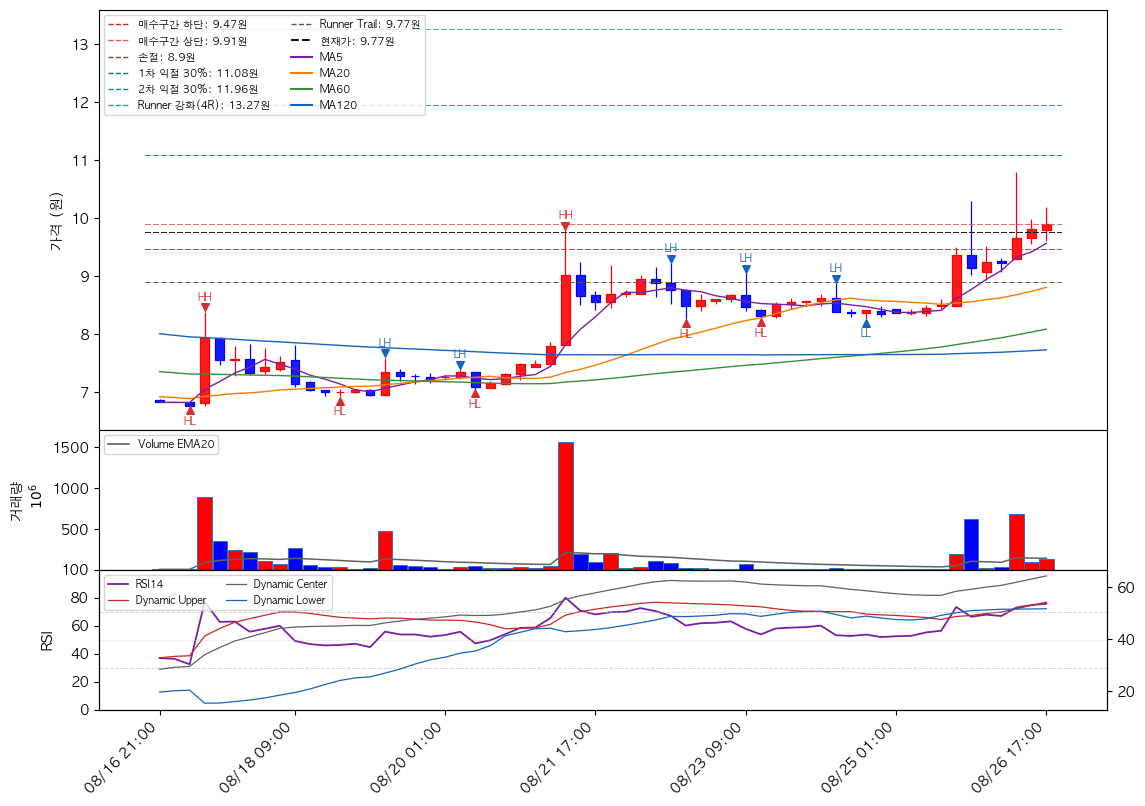

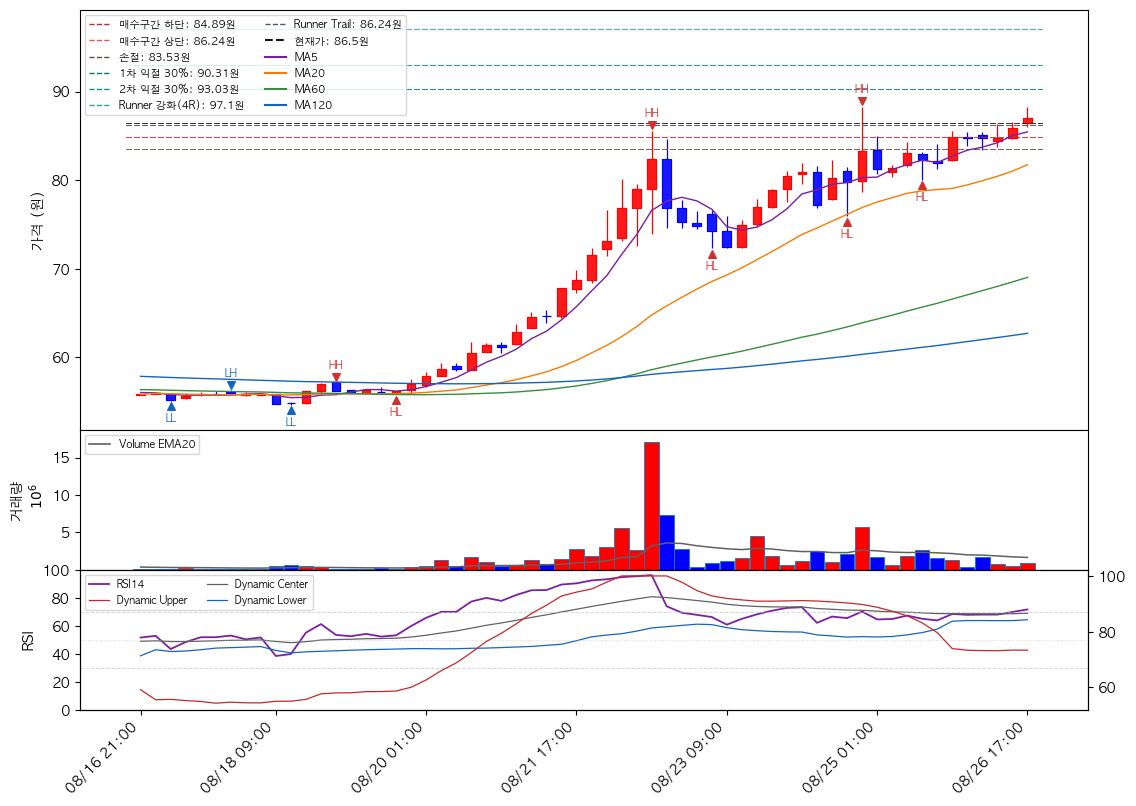

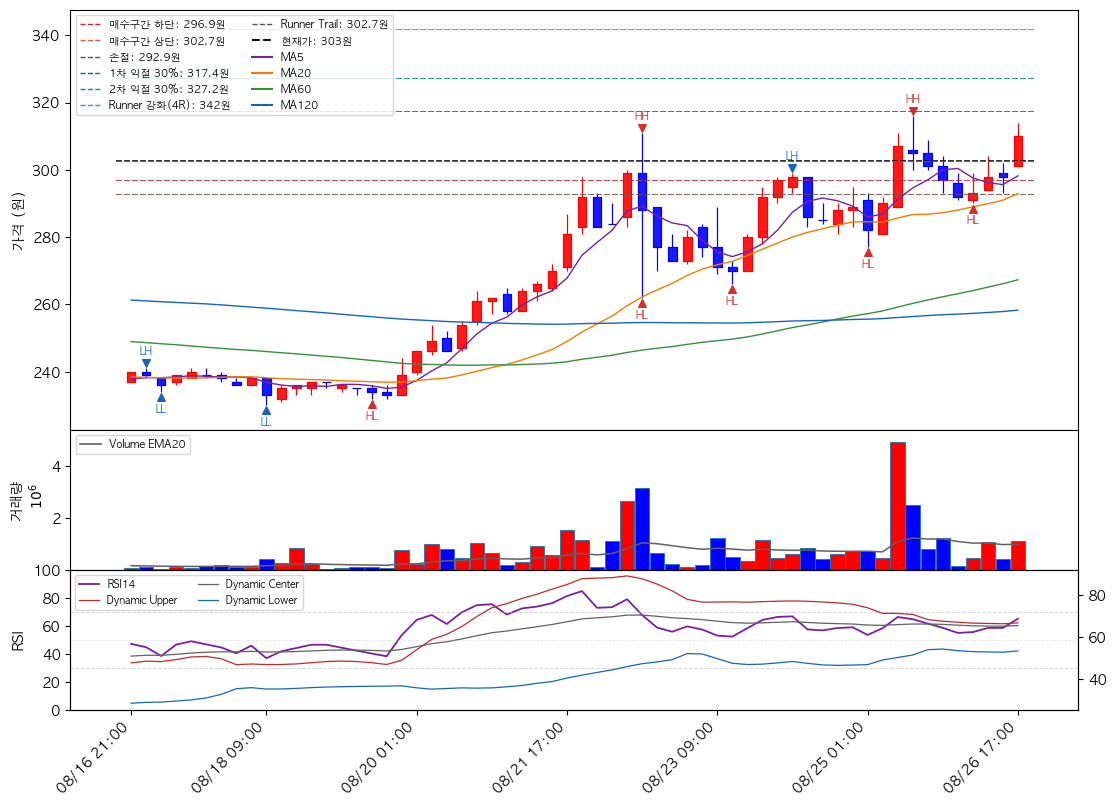

In [14]:
# 원하는 설정으로 직접 실행
settings = Settings(
    min_change_24h=1.0,
    max_change_24h=30.0,
    min_trade_value_24h=100_000_000,
    account_capital=100_000_000,
    risk_per_trade_pct=0.5,
    max_position_pct=20.0,
    top_n=20,
    strategy_n=5,
    chart_n=3,
)

result = run_analysis(settings, on_progress=lambda r, m: print(f"[{r:5.0%}] {m}", end="\r"))
print()
show_report(result)

In [15]:
# 결과를 데이터프레임으로 직접 다루기
table = result.result_table

print("후보 수:", len(table))
print("BTC 국면:", result.btc_regime.get("label"), "| 점수:", result.btc_regime.get("score"))
print("캔들 출처 240m:", result.source_240m)
print("캔들 출처  60m:", result.source_60m)

# 예: '매수 관심' 계열만 추려 보기
interest = table[table["final_action"].str.contains("매수", na=False)]
display(interest[["symbol", "korean_name", "final_action", "final_score",
                  "price", "buy_zone_low", "buy_zone_high", "stop_price"]].head(10))

# CSV로 저장
table.to_csv("upbit_result.csv", index=False, encoding="utf-8-sig")
print("저장 완료: upbit_result.csv")

후보 수: 24
BTC 국면: Q3 Strong | 점수: 3
캔들 출처 240m: {'api': 0, 'cache': 266, 'stale': 0, 'missing': 0}
캔들 출처  60m: {'api': 0, 'cache': 24, 'stale': 0, 'missing': 0}


,symbol,korean_name,final_action,final_score,price,buy_zone_low,buy_zone_high,stop_price
1,KRW-MINA,미나,매수 관심,87.0,86.5,84.886429,86.243571,83.529286
2,KRW-JUP,주피터,분할매수 관심,82.7,303.0,296.871429,302.728571,292.921429
6,KRW-STX,스택스,매수 관심,70.0,382.0,368.121429,380.978571,355.264286
7,KRW-META,메타디움,매수 관심,68.6,10.4,10.022857,10.217143,9.956190
10,KRW-SPX,에스피엑스6900,분할매수 관심,63.0,740.0,726.042857,744.257143,703.571429


저장 완료: upbit_result.csv
